In [23]:
# ============================================================
# Cell 1: Imports and Setup
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
import string
import time
import warnings
warnings.filterwarnings('ignore')

# NLP-specific imports
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, SimpleRNN, LSTM, Dense, Dropout,
    Bidirectional, GlobalMaxPooling1D, SpatialDropout1D
)
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score

# Set random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")
print("All libraries imported successfully")

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
All libraries imported successfully


In [24]:
# ============================================================
# Cell 2: Load the dataset and initial exploration
# ============================================================

# Find the dataset path
DATA_DIR = '/kaggle/input'
for root, dirs, files in os.walk(DATA_DIR):
    for f in files:
        if f.endswith('.csv'):
            print(os.path.join(root, f))

/kaggle/input/datasets/sandipdhakal4242/hate-speech-6cs012/7. Racist Sexist or Not Dataset/test_racisit.csv
/kaggle/input/datasets/sandipdhakal4242/hate-speech-6cs012/7. Racist Sexist or Not Dataset/train_racisit.csv
/kaggle/input/notebooks/sandipdhakal4242/2408003-sandipdhakal-text-classification/test_predictions.csv


In [25]:
# ============================================================
# Cell 3: Load training and test datasets
# ============================================================

# Define exact paths
BASE_DIR = '/kaggle/input/datasets/sandipdhakal4242/hate-speech-6cs012/7. Racist Sexist or Not Dataset'
TRAIN_PATH = os.path.join(BASE_DIR, 'train_racisit.csv')
TEST_PATH = os.path.join(BASE_DIR, 'test_racisit.csv')

# Load both files
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

# --- Quick inspection ---
print(f"Training shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")
print()
print("Training columns:", list(train_df.columns))
print("Test columns:", list(test_df.columns))
print()
print("--- First 5 training rows ---")
print(train_df.head())
print()
print("--- First 5 test rows ---")
print(test_df.head())
print()
print("--- Data types ---")
print(train_df.dtypes)
print()
print("--- Missing values ---")
print("Train:", train_df.isnull().sum().sum())
print("Test:", test_df.isnull().sum().sum())

Training shape: (31962, 3)
Test shape: (17197, 2)

Training columns: ['id', 'label', 'tweet']
Test columns: ['id', 'tweet']

--- First 5 training rows ---
   id  label                                              tweet
0   1      0   @user when a father is dysfunctional and is s...
1   2      0  @user @user thanks for #lyft credit i can't us...
2   3      0                                bihday your majesty
3   4      0  #model   i love u take with u all the time in ...
4   5      0             factsguide: society now    #motivation

--- First 5 test rows ---
      id                                              tweet
0  31963  #studiolife #aislife #requires #passion #dedic...
1  31964   @user #white #supremacists want everyone to s...
2  31965  safe ways to heal your #acne!!    #altwaystohe...
3  31966  is the hp and the cursed child book up for res...
4  31967    3rd #bihday to my amazing, hilarious #nephew...

--- Data types ---
id        int64
label     int64
tweet    object
dtype:

Class distribution:
   Label 0 (non-hateful): 29,720 (92.99%)
   Label 1 (racist/sexist): 2,242 (7.01%)
   Imbalance ratio: 13.26



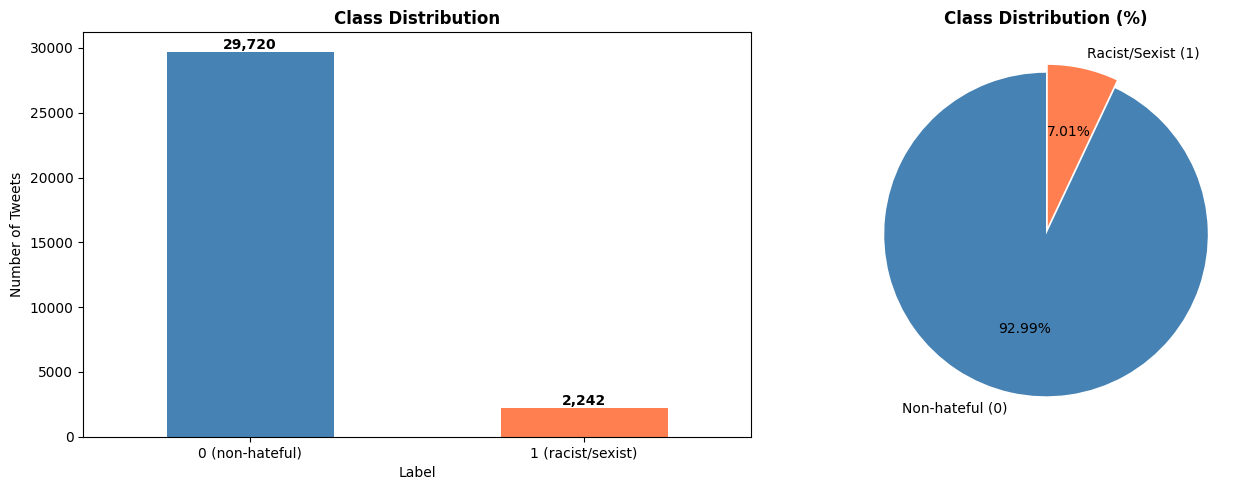

In [26]:
# ============================================================
# Cell 4: Class distribution and basic statistics
# ============================================================

# --- Class distribution ---
class_counts = train_df['label'].value_counts().sort_index()
print("Class distribution:")
print(f"   Label 0 (non-hateful): {class_counts[0]:,} ({class_counts[0]/len(train_df)*100:.2f}%)")
print(f"   Label 1 (racist/sexist): {class_counts[1]:,} ({class_counts[1]/len(train_df)*100:.2f}%)")
print(f"   Imbalance ratio: {class_counts[0]/class_counts[1]:.2f}")
print()

# --- Visualize class distribution ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
class_counts.plot(kind='bar', ax=axes[0], color=['steelblue', 'coral'])
axes[0].set_title('Class Distribution', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Number of Tweets')
axes[0].set_xticklabels(['0 (non-hateful)', '1 (racist/sexist)'], rotation=0)
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(class_counts.values,
            labels=['Non-hateful (0)', 'Racist/Sexist (1)'],
            autopct='%1.2f%%',
            colors=['steelblue', 'coral'],
            startangle=90,
            explode=(0, 0.05))
axes[1].set_title('Class Distribution (%)', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

Tweet length statistics (characters):
count    31962.0
mean        84.7
std         29.5
min         11.0
25%         63.0
50%         88.0
75%        108.0
max        274.0
Name: char_count, dtype: float64

Tweet length statistics (words):
count    31962.0
mean        13.2
std          5.5
min          3.0
25%          9.0
50%         13.0
75%         17.0
max         34.0
Name: word_count, dtype: float64

Average length by class:
       char_count  word_count
label                        
0            84.3        13.1
1            90.2        14.1



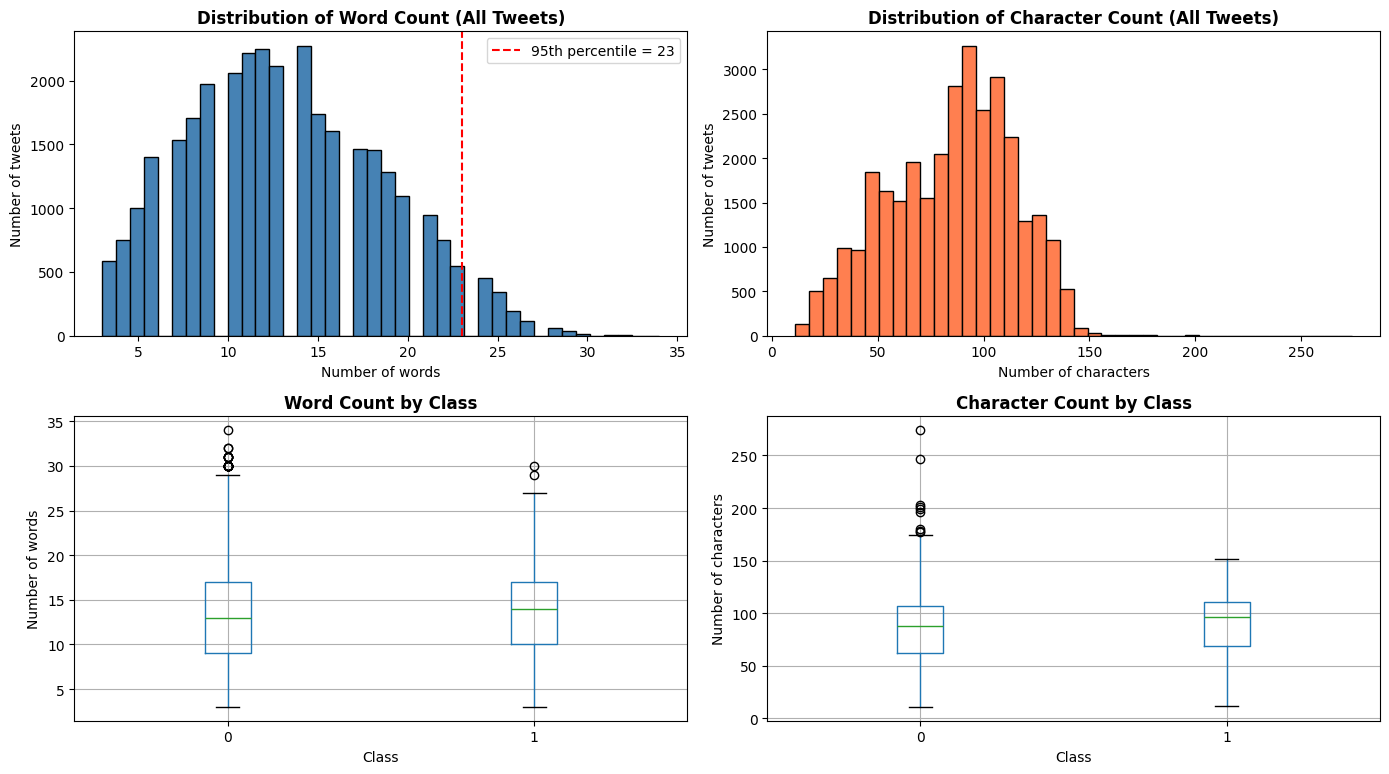


95th percentile word count = 23
   → We'll use this as MAX_LENGTH for padding sequences later


In [27]:
# ============================================================
# Cell 5: Tweet length analysis
# ============================================================

# Calculate length features per tweet
train_df['char_count'] = train_df['tweet'].str.len()
train_df['word_count'] = train_df['tweet'].str.split().str.len()

# Print summary statistics
print("Tweet length statistics (characters):")
print(train_df['char_count'].describe().round(1))
print()
print("Tweet length statistics (words):")
print(train_df['word_count'].describe().round(1))
print()

# Compare lengths between classes
print("Average length by class:")
print(train_df.groupby('label').agg({
    'char_count': 'mean',
    'word_count': 'mean'
}).round(1))
print()

# Visualize length distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Word count histogram (overall)
axes[0, 0].hist(train_df['word_count'], bins=40, color='steelblue', edgecolor='black')
axes[0, 0].set_title('Distribution of Word Count (All Tweets)', fontweight='bold')
axes[0, 0].set_xlabel('Number of words')
axes[0, 0].set_ylabel('Number of tweets')
axes[0, 0].axvline(train_df['word_count'].quantile(0.95), color='red', linestyle='--', 
                    label=f"95th percentile = {train_df['word_count'].quantile(0.95):.0f}")
axes[0, 0].legend()

# Character count histogram (overall)
axes[0, 1].hist(train_df['char_count'], bins=40, color='coral', edgecolor='black')
axes[0, 1].set_title('Distribution of Character Count (All Tweets)', fontweight='bold')
axes[0, 1].set_xlabel('Number of characters')
axes[0, 1].set_ylabel('Number of tweets')

# Word count by class (boxplot)
train_df.boxplot(column='word_count', by='label', ax=axes[1, 0])
axes[1, 0].set_title('Word Count by Class', fontweight='bold')
axes[1, 0].set_xlabel('Class')
axes[1, 0].set_ylabel('Number of words')
plt.suptitle('')  # remove auto-suptitle from boxplot

# Character count by class
train_df.boxplot(column='char_count', by='label', ax=axes[1, 1])
axes[1, 1].set_title('Character Count by Class', fontweight='bold')
axes[1, 1].set_xlabel('Class')
axes[1, 1].set_ylabel('Number of characters')
plt.suptitle('')

plt.tight_layout()
plt.show()

# Critical metric for padding decision
PAD_LENGTH = int(train_df['word_count'].quantile(0.95))
print(f"\n95th percentile word count = {PAD_LENGTH}")
print(f"   → We'll use this as MAX_LENGTH for padding sequences later")

In [28]:
# ============================================================
# Cell 6: View sample tweets from each class
# ============================================================

print("="*70)
print("SAMPLE NON-HATEFUL TWEETS (label=0)")
print("="*70)
samples_0 = train_df[train_df['label'] == 0]['tweet'].sample(10, random_state=SEED).tolist()
for i, tweet in enumerate(samples_0, 1):
    print(f"{i}. {tweet[:200]}")
    print()

print("\n" + "="*70)
print("SAMPLE RACIST/SEXIST TWEETS (label=1)")
print("="*70)
samples_1 = train_df[train_df['label'] == 1]['tweet'].sample(10, random_state=SEED).tolist()
for i, tweet in enumerate(samples_1, 1):
    print(f"{i}. {tweet[:200]}")
    print()

SAMPLE NON-HATEFUL TWEETS (label=0)
1. #body to body massage with a   ending oil #massage ,body happyending massage center abu dhabi ,0506823156 

2.  @user @ my call back!  #casting #castingcall #model #cute #toddler #toddlerlife #photooftheday #nofilter #family   httâ¦

3. help creates the #environment of #togetherness &amp; #mutualrespect; prerequisites of a #sustainable,   and #healthy society.#fridayfeeling

4. summer with friendâ¨ð¥ #summer  #friend #life #vlog #weeknd   #crazy  i'll miss youð¼ð 

5. follow me on snapchat at awesomecutenes7 #snapchat #selfie #sad   #love #bff #yaaaaasssâ¦ 

6.  @user robbie told @user about #thesmb which lead to being asked to broadcast @user #blessed   #spats2016 

7. cupcakes! #beachpay #payplanning #friends  #enough #justwannabeme 

8. such a happy boyð love this guy #littleman #loveofmylife #littlebuddy #smile   #bestbuddyâ¦ 

9. this keshi's news is really hard for me to accept. #sosudden  

10.   days porn movie skinny amateur

In [29]:
# ============================================================
# Cell 7: Text preprocessing pipeline
#   lowercase -> URLs -> @mentions -> # symbol -> HTML entities
#   -> RT marker -> non-ASCII -> contractions -> digits -> punctuation
#   -> whitespace collapse -> stopword removal -> lemmatization
# ============================================================

import re
import string
import nltk

# Download required NLTK data (idempotent across re-runs)
for resource in ['stopwords', 'wordnet', 'omw-1.4']:
    try:
        nltk.download(resource, quiet=True)
    except Exception:
        pass

from nltk.corpus import stopwords as nltk_stopwords
from nltk.stem import WordNetLemmatizer

# --- Contractions map (most common Twitter / English forms) ---
CONTRACTIONS = {
    "don't": "do not", "doesn't": "does not", "didn't": "did not",
    "won't": "will not", "wouldn't": "would not", "couldn't": "could not",
    "shouldn't": "should not", "can't": "cannot", "ain't": "is not",
    "aren't": "are not", "isn't": "is not", "wasn't": "was not",
    "weren't": "were not", "hasn't": "has not", "haven't": "have not",
    "hadn't": "had not", "i'm": "i am", "i've": "i have", "i'll": "i will",
    "i'd": "i would", "you're": "you are", "you've": "you have",
    "you'll": "you will", "you'd": "you would", "he's": "he is",
    "he'll": "he will", "he'd": "he would", "she's": "she is",
    "she'll": "she will", "she'd": "she would", "it's": "it is",
    "it'll": "it will", "it'd": "it would", "we're": "we are",
    "we've": "we have", "we'll": "we will", "we'd": "we would",
    "they're": "they are", "they've": "they have", "they'll": "they will",
    "they'd": "they would", "that's": "that is", "that'll": "that will",
    "what's": "what is", "what're": "what are", "where's": "where is",
    "who's": "who is", "let's": "let us", "y'all": "you all",
    "gonna": "going to", "wanna": "want to", "gotta": "got to",
    "lemme": "let me", "gimme": "give me",
}

_CONTRACTION_RE = re.compile(
    r"\b(" + "|".join(re.escape(k) for k in CONTRACTIONS) + r")\b",
    flags=re.IGNORECASE,
)

def expand_contractions(text):
    return _CONTRACTION_RE.sub(lambda m: CONTRACTIONS[m.group(0).lower()], text)


# --- Lemmatizer + stopword set (built once) ---
lemmatizer = WordNetLemmatizer()
STOPWORDS  = set(nltk_stopwords.words('english'))
# Keep negations -- they carry signal in hate-speech context
for _keep in ['not', 'no', 'nor', 'never', 'against']:
    STOPWORDS.discard(_keep)


def clean_text(text):
    """Full preprocessing pipeline returning a cleaned tweet string."""
    # 1. Lowercase
    text = text.lower()
    # 2. Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    # 3. Remove @user mentions
    text = re.sub(r'@\w+', '', text)
    # 4. Strip # symbol, keep the word (e.g. #hate -> hate)
    text = re.sub(r'#', '', text)
    # 5. Remove HTML entities (&amp; &lt; ...)
    text = re.sub(r'&\w+;', ' ', text)
    # 6. Remove RT retweet marker
    text = re.sub(r'\brt\b', '', text)
    # 7. Remove non-ASCII (emoji, special unicode)
    text = text.encode('ascii', 'ignore').decode('ascii')
    # 8. Expand contractions (must run before punctuation removal!)
    text = expand_contractions(text)
    # 9. Remove digits
    text = re.sub(r'\d+', '', text)
    # 10. Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # 11. Collapse whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    # 12. Tokenize -> drop stopwords -> lemmatize -> rejoin
    tokens = [
        lemmatizer.lemmatize(tok)
        for tok in text.split()
        if tok and tok not in STOPWORDS
    ]
    return ' '.join(tokens)


# --- Apply cleaning to all tweets ---
print("Cleaning training tweets...")
train_df['cleaned_tweet'] = train_df['tweet'].apply(clean_text)

print("Cleaning test tweets...")
test_df['cleaned_tweet']  = test_df['tweet'].apply(clean_text)
print("Done.\n")

# --- Before / after examples ---
print("="*70)
print("BEFORE vs AFTER cleaning examples")
print("="*70)
for i in [0, 1, 2, 5, 100]:
    print(f"\nOriginal: {train_df['tweet'].iloc[i][:150]}")
    print(f"Cleaned:  {train_df['cleaned_tweet'].iloc[i][:150]}")
    print(f"Label:    {train_df['label'].iloc[i]}")

# --- Edge cases / summary stats ---
empty_count = (train_df['cleaned_tweet'].str.len() == 0).sum()
print(f"\n\nEmpty tweets after cleaning (training): {empty_count}")

train_df['cleaned_word_count'] = train_df['cleaned_tweet'].str.split().str.len()
print(f"Word count AFTER cleaning -- mean: {train_df['cleaned_word_count'].mean():.1f}, "
      f"95th %ile: {train_df['cleaned_word_count'].quantile(0.95):.0f}")


Cleaning training tweets...
Cleaning test tweets...
Done.

BEFORE vs AFTER cleaning examples

Original:  @user when a father is dysfunctional and is so selfish he drags his kids into his dysfunction.   #run
Cleaned:  father dysfunctional selfish drag kid dysfunction run
Label:    0

Original: @user @user thanks for #lyft credit i can't use cause they don't offer wheelchair vans in pdx.    #disapointed #getthanked
Cleaned:  thanks lyft credit cannot use cause not offer wheelchair van pdx disapointed getthanked
Label:    0

Original:   bihday your majesty
Cleaned:  bihday majesty
Label:    0

Original: [2/2] huge fan fare and big talking before they leave. chaos and pay disputes when they get there. #allshowandnogo  
Cleaned:  huge fan fare big talking leave chaos pay dispute get allshowandnogo
Label:    0

Original: there are some truly sick ppl out there.   
Cleaned:  truly sick ppl
Label:    0


Empty tweets after cleaning (training): 33
Word count AFTER cleaning -- mean: 7.7, 95th %i

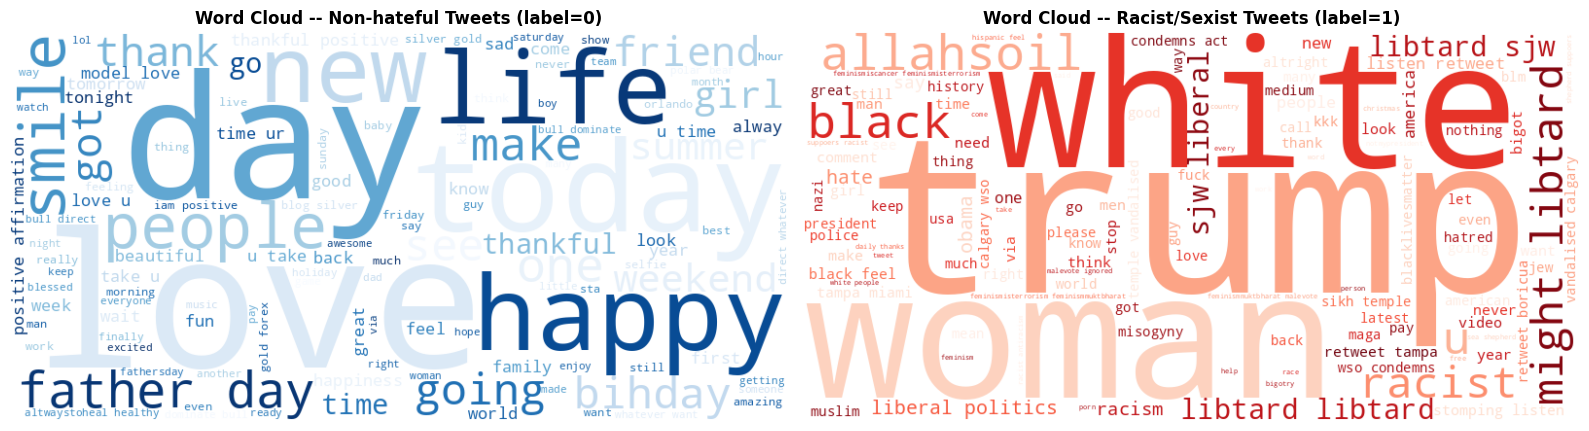

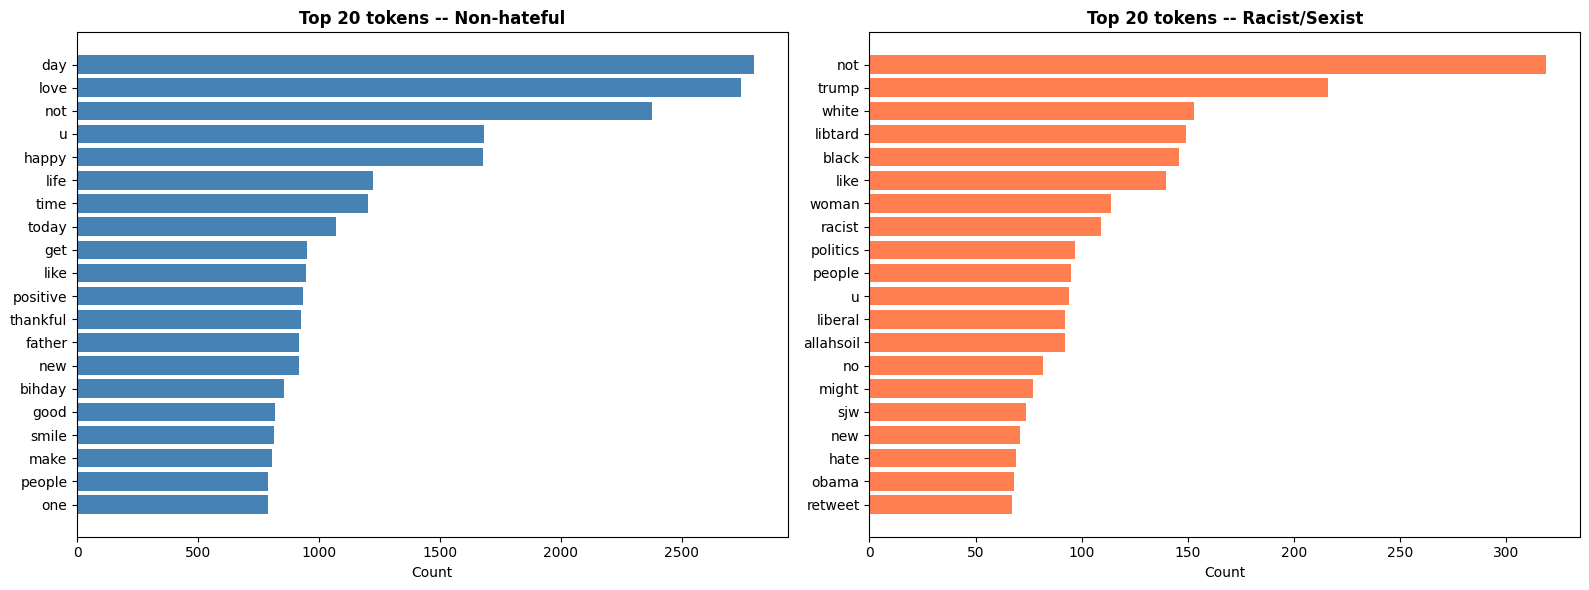

Top 10 tokens overall (cleaned corpus):
   day              2,813
   love             2,774
   not              2,695
   u                1,777
   happy            1,691
   life             1,235
   time             1,234
   like             1,088
   today            1,086
   get              1,000


In [30]:
# ============================================================
# Cell 7b: Word cloud + most frequent tokens (post-cleaning)
# ============================================================

from collections import Counter

# Install wordcloud if missing (Kaggle / Colab safe)
try:
    from wordcloud import WordCloud
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'wordcloud'])
    from wordcloud import WordCloud


def get_top_tokens(series, n=20):
    counter = Counter()
    for txt in series.dropna():
        counter.update(txt.split())
    return counter.most_common(n)


non_hate_text = ' '.join(train_df.loc[train_df['label'] == 0, 'cleaned_tweet'])
hate_text     = ' '.join(train_df.loc[train_df['label'] == 1, 'cleaned_tweet'])

# --- Word clouds (per class) ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

wc_non = WordCloud(width=800, height=400, background_color='white',
                   colormap='Blues', max_words=120).generate(non_hate_text)
axes[0].imshow(wc_non, interpolation='bilinear')
axes[0].set_title('Word Cloud -- Non-hateful Tweets (label=0)', fontweight='bold')
axes[0].axis('off')

wc_hate = WordCloud(width=800, height=400, background_color='white',
                    colormap='Reds', max_words=120).generate(hate_text)
axes[1].imshow(wc_hate, interpolation='bilinear')
axes[1].set_title('Word Cloud -- Racist/Sexist Tweets (label=1)', fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()


# --- Top-20 frequent tokens per class (bar chart) ---
top_non  = get_top_tokens(train_df.loc[train_df['label'] == 0, 'cleaned_tweet'], n=20)
top_hate = get_top_tokens(train_df.loc[train_df['label'] == 1, 'cleaned_tweet'], n=20)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

words_n, counts_n = zip(*top_non)
axes[0].barh(range(len(words_n)), counts_n, color='steelblue')
axes[0].set_yticks(range(len(words_n)))
axes[0].set_yticklabels(words_n)
axes[0].invert_yaxis()
axes[0].set_title('Top 20 tokens -- Non-hateful', fontweight='bold')
axes[0].set_xlabel('Count')

words_h, counts_h = zip(*top_hate)
axes[1].barh(range(len(words_h)), counts_h, color='coral')
axes[1].set_yticks(range(len(words_h)))
axes[1].set_yticklabels(words_h)
axes[1].invert_yaxis()
axes[1].set_title('Top 20 tokens -- Racist/Sexist', fontweight='bold')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.show()


print("Top 10 tokens overall (cleaned corpus):")
for w, c in get_top_tokens(train_df['cleaned_tweet'], n=10):
    print(f"   {w:15s}  {c:,}")


In [31]:
# ============================================================
# Cell 8: Tokenize text and create train/validation split
# ============================================================

# --- Hyperparameters for tokenization ---
VOCAB_SIZE = 10000
MAX_LENGTH = 25
EMBEDDING_DIM = 100
OOV_TOKEN = "<OOV>"

# --- Drop the 2 empty tweets ---
train_df = train_df[train_df['cleaned_tweet'].str.len() > 0].reset_index(drop=True)
print(f"Training set after dropping empty: {len(train_df):,}")

# --- Train/Val split BEFORE tokenizing ---
X = train_df['cleaned_tweet'].values
y = train_df['label'].values

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print()
print(f"Train split: {len(X_train):,} | non-hateful: {sum(y_train==0):,} | hateful: {sum(y_train==1):,}")
print(f"Val split:   {len(X_val):,} | non-hateful: {sum(y_val==0):,} | hateful: {sum(y_val==1):,}")

# --- Build tokenizer on training data only ---
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(X_train)

print()
print(f"Total unique words found in training: {len(tokenizer.word_index):,}")
print(f"Vocabulary size used (top {VOCAB_SIZE}): {min(VOCAB_SIZE, len(tokenizer.word_index)):,}")

# --- Text to sequences ---
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)
X_test_seq = tokenizer.texts_to_sequences(test_df['cleaned_tweet'].values)

# --- Pad sequences ---
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LENGTH, padding='post', truncating='post')
X_val_pad = pad_sequences(X_val_seq, maxlen=MAX_LENGTH, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LENGTH, padding='post', truncating='post')

print()
print("Shape of padded sequences:")
print(f"   Training:   {X_train_pad.shape}")
print(f"   Validation: {X_val_pad.shape}")
print(f"   Test:       {X_test_pad.shape}")

# --- Sanity check: example tokenization ---
print()
print("Example tokenization:")
print(f"Original text:  {X_train[0]}")
print(f"As tokens:      {X_train_seq[0]}")
print(f"After padding:  {X_train_pad[0]}")

print()
print("Top 20 vocabulary words:")
for word, idx in list(tokenizer.word_index.items())[:20]:
    print(f"   {idx:4d}: {word}")

Training set after dropping empty: 31,929

Train split: 25,543 | non-hateful: 23,752 | hateful: 1,791
Val split:   6,386 | non-hateful: 5,938 | hateful: 448

Total unique words found in training: 32,199
Vocabulary size used (top 10000): 10,000

Shape of padded sequences:
   Training:   (25543, 25)
   Validation: (6386, 25)
   Test:       (17197, 25)

Example tokenization:
Original text:  father happy weekend everyone
As tokens:      [13, 6, 31, 113]
After padding:  [ 13   6  31 113   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0]

Top 20 vocabulary words:
      1: <OOV>
      2: day
      3: love
      4: not
      5: u
      6: happy
      7: time
      8: life
      9: like
     10: today
     11: get
     12: new
     13: father
     14: positive
     15: thankful
     16: people
     17: bihday
     18: good
     19: make
     20: one


In [32]:
# ============================================================
# Cell 9: Compute class weights to handle imbalance
# ============================================================

from sklearn.utils.class_weight import compute_class_weight

# Compute balanced class weights from training labels
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=y_train
)

# Convert to dict format that Keras expects: {class_idx: weight}
class_weights = {0: class_weights_array[0], 1: class_weights_array[1]}

print("Class weights for handling 93/7 imbalance:")
print(f"   Class 0 (non-hateful): weight = {class_weights[0]:.4f}")
print(f"   Class 1 (racist/sexist): weight = {class_weights[1]:.4f}")
print()
print("Interpretation:")
print(f"   Each hateful tweet contributes {class_weights[1]/class_weights[0]:.1f}x more to the loss")
print(f"   This forces the model to pay attention to the minority class")

Class weights for handling 93/7 imbalance:
   Class 0 (non-hateful): weight = 0.5377
   Class 1 (racist/sexist): weight = 7.1309

Interpretation:
   Each hateful tweet contributes 13.3x more to the loss
   This forces the model to pay attention to the minority class


In [33]:
# ============================================================
# Cell 10: Model 1 — SimpleRNN with trainable embedding
# ============================================================

# --- Build the SimpleRNN model ---
def build_simple_rnn():
    model = Sequential(name='SimpleRNN_Model')
    
    # Embedding layer: maps word indices to dense 100-dim vectors
    # Trainable (learns from scratch during training)
    model.add(Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        input_length=MAX_LENGTH,
        mask_zero=True             # tells model that 0=padding, ignore those positions
    ))
    
    # SpatialDropout1D drops entire word embeddings (better than regular dropout for embeddings)
    model.add(SpatialDropout1D(0.2))
    
    # SimpleRNN layer: 64 units, with internal regularization
    model.add(SimpleRNN(
        units=64,
        dropout=0.2,
        recurrent_dropout=0.2
    ))
    
    # Final dense layer for binary classification
    model.add(Dense(1, activation='sigmoid'))
    
    return model


# --- Build and compile ---
simple_rnn_model = build_simple_rnn()
simple_rnn_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',          # binary classification loss
    metrics=['accuracy', 
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

# Show summary
simple_rnn_model.summary()

Model: "SimpleRNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_2             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [34]:
# Force the model to build by specifying input shape
simple_rnn_model.build(input_shape=(None, MAX_LENGTH))
simple_rnn_model.summary()

Model: "SimpleRNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 25, 100)        │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_2             │ (None, 25, 100)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 64)             │        10,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,010,625 (3.86 MB)

 Trainable params: 1,010,625 (3.86 MB)

 Non-trainable params: 0 (0.00 B)

In [35]:
# ============================================================
# Cell 11: Train SimpleRNN model
# ============================================================

# Early stopping based on val_loss
early_stop_rnn = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

# Train
print("Training SimpleRNN model...")
print()

start_time = time.time()

history_rnn = simple_rnn_model.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=10,
    batch_size=64,
    class_weight=class_weights,        # CRITICAL for imbalanced data
    callbacks=[early_stop_rnn],
    verbose=1
)

training_time_rnn = time.time() - start_time
print(f"\n{'='*50}")
print(f"SimpleRNN training completed in {training_time_rnn:.1f}s ({training_time_rnn/60:.2f} min)")
print(f"{'='*50}")

Training SimpleRNN model...

Epoch 1/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.6857 - loss: 0.5647 - precision: 0.1570 - recall: 0.7067 - val_accuracy: 0.8959 - val_loss: 0.2448 - val_precision: 0.3857 - val_recall: 0.8170
Epoch 2/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9140 - loss: 0.2153 - precision: 0.4538 - recall: 0.9250 - val_accuracy: 0.9219 - val_loss: 0.1970 - val_precision: 0.4665 - val_recall: 0.7924
Epoch 3/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9501 - loss: 0.1297 - precision: 0.5963 - recall: 0.9635 - val_accuracy: 0.9336 - val_loss: 0.1910 - val_precision: 0.5189 - val_recall: 0.7366
Epoch 4/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9654 - loss: 0.0832 - precision: 0.6841 - recall: 0.9729 - val_accuracy: 0.9314 - val_loss: 0.2041 - val_precision: 0.5078 - val_recall: 0.7254
Epoch 5/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9744 - loss: 0.0634 - precision: 0.7440 - recall: 0.9852 - val_

Generating predictions on validation set...

SIMPLE-RNN CLASSIFICATION REPORT (threshold = 0.5)
               precision    recall  f1-score   support

  non-hateful     0.9795    0.9485    0.9637      5938
racist/sexist     0.5189    0.7366    0.6089       448

     accuracy                         0.9336      6386
    macro avg     0.7492    0.8425    0.7863      6386
 weighted avg     0.9472    0.9336    0.9388      6386



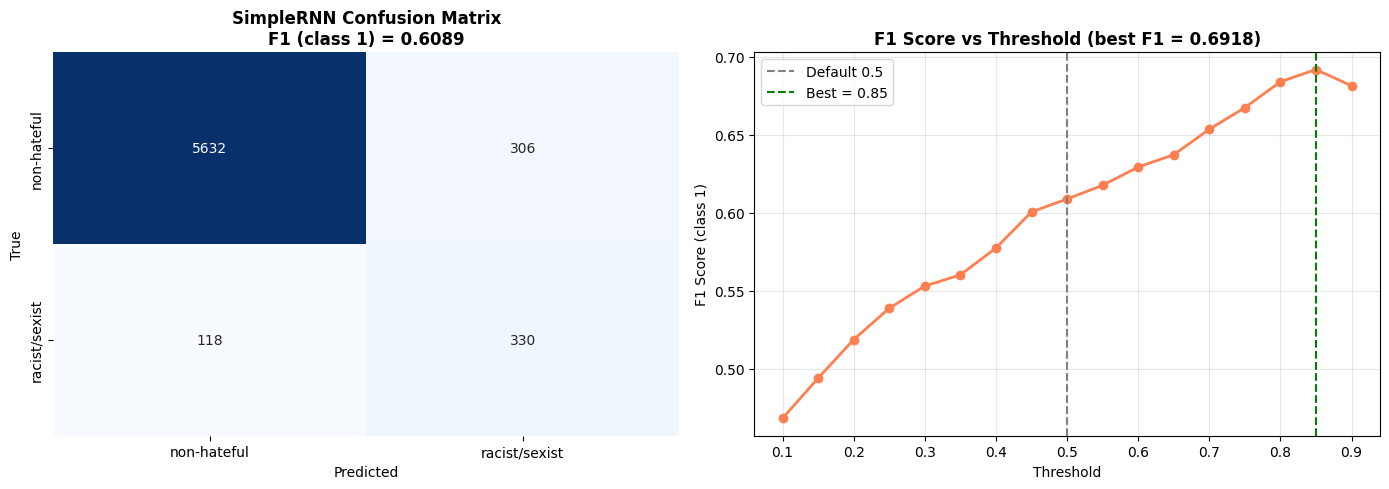


=== AT OPTIMAL THRESHOLD (0.85) ===
               precision    recall  f1-score   support

  non-hateful     0.9743    0.9818    0.9780      5938
racist/sexist     0.7313    0.6562    0.6918       448

     accuracy                         0.9590      6386
    macro avg     0.8528    0.8190    0.8349      6386
 weighted avg     0.9572    0.9590    0.9579      6386


📊 SimpleRNN summary saved for comparison


In [36]:
# ============================================================
# Cell 12: Evaluate SimpleRNN with all metrics
# ============================================================

# --- Generate predictions ---
print("Generating predictions on validation set...")
y_val_proba_rnn = simple_rnn_model.predict(X_val_pad, verbose=0).flatten()

# Default threshold = 0.5
y_val_pred_rnn = (y_val_proba_rnn > 0.5).astype(int)

# --- Classification report ---
print("\n" + "="*65)
print("SIMPLE-RNN CLASSIFICATION REPORT (threshold = 0.5)")
print("="*65)
print(classification_report(y_val, y_val_pred_rnn, 
                           target_names=['non-hateful', 'racist/sexist'],
                           digits=4))

# --- Confusion matrix ---
cm_rnn = confusion_matrix(y_val, y_val_pred_rnn)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix plot
sns.heatmap(cm_rnn, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['non-hateful', 'racist/sexist'],
            yticklabels=['non-hateful', 'racist/sexist'],
            cbar=False)
axes[0].set_title(f'SimpleRNN Confusion Matrix\nF1 (class 1) = {f1_score(y_val, y_val_pred_rnn):.4f}', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

# --- Threshold tuning: find best F1 ---
thresholds = np.arange(0.1, 0.91, 0.05)
f1_scores = []
for t in thresholds:
    preds = (y_val_proba_rnn > t).astype(int)
    f1_scores.append(f1_score(y_val, preds))

# Plot F1 vs threshold
axes[1].plot(thresholds, f1_scores, marker='o', linewidth=2, color='coral')
axes[1].axvline(0.5, color='gray', linestyle='--', label='Default 0.5')
best_t = thresholds[np.argmax(f1_scores)]
axes[1].axvline(best_t, color='green', linestyle='--', label=f'Best = {best_t:.2f}')
axes[1].set_title(f'F1 Score vs Threshold (best F1 = {max(f1_scores):.4f})', fontweight='bold')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('F1 Score (class 1)')
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

# --- Show results at optimal threshold ---
y_val_pred_best = (y_val_proba_rnn > best_t).astype(int)
print(f"\n=== AT OPTIMAL THRESHOLD ({best_t:.2f}) ===")
print(classification_report(y_val, y_val_pred_best,
                           target_names=['non-hateful', 'racist/sexist'],
                           digits=4))

# Save key metrics for comparison later
rnn_results = {
    'name': 'SimpleRNN',
    'val_accuracy': (y_val_pred_rnn == y_val).mean(),
    'val_f1_default': f1_score(y_val, y_val_pred_rnn),
    'val_f1_best': max(f1_scores),
    'best_threshold': best_t,
    'training_time': training_time_rnn
}
print(f"\n📊 SimpleRNN summary saved for comparison")

In [37]:
# ============================================================
# Cell 13: Model 2 — LSTM with trainable embedding (Bidirectional)
# ============================================================

def build_lstm():
    model = Sequential(name='LSTM_Model')
    model.add(tf.keras.Input(shape=(MAX_LENGTH,)))
    model.add(Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        mask_zero=True
    ))
    model.add(SpatialDropout1D(0.2))
    
    # Bidirectional LSTM: reads tweet left-to-right AND right-to-left
    # Output is concatenated → 64*2 = 128 dims
    model.add(Bidirectional(LSTM(
        units=64,
        dropout=0.2,
        recurrent_dropout=0.2
    )))
    
    # Optional dense layer for additional learning capacity
    model.add(Dense(32, activation='relu'))
    model.add(Dropout(0.3))
    
    # Output
    model.add(Dense(1, activation='sigmoid'))
    
    return model


lstm_model = build_lstm()
lstm_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)
lstm_model.summary()

Model: "LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 25, 100)        │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_3             │ (None, 25, 100)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │        84,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,088,641 (4.15 MB)

 Trainable params: 1,088,641 (4.15 MB)

 Non-trainable params: 0 (0.00 B)

In [38]:
# ============================================================
# Cell 14: Train LSTM model
# ============================================================

early_stop_lstm = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

print("Training LSTM model...")
print()

start_time = time.time()

history_lstm = lstm_model.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=10,
    batch_size=64,
    class_weight=class_weights,
    callbacks=[early_stop_lstm],
    verbose=1
)

training_time_lstm = time.time() - start_time
print(f"\n{'='*50}")
print(f"LSTM training completed in {training_time_lstm:.1f}s ({training_time_lstm/60:.2f} min)")
print(f"{'='*50}")

Training LSTM model...

Epoch 1/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 72s 161ms/step - accuracy: 0.7645 - loss: 0.5190 - precision: 0.2033 - recall: 0.7340 - val_accuracy: 0.9339 - val_loss: 0.2087 - val_precision: 0.5190 - val_recall: 0.7946
Epoch 2/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 63s 158ms/step - accuracy: 0.9353 - loss: 0.1834 - precision: 0.5305 - recall: 0.9307 - val_accuracy: 0.9302 - val_loss: 0.1849 - val_precision: 0.5015 - val_recall: 0.7589
Epoch 3/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 62s 155ms/step - accuracy: 0.9554 - loss: 0.1176 - precision: 0.6271 - recall: 0.9481 - val_accuracy: 0.9449 - val_loss: 0.1769 - val_precision: 0.5882 - val_recall: 0.7143
Epoch 4/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 63s 156ms/step - accuracy: 0.9750 - loss: 0.0679 - precision: 0.7518 - recall: 0.9783 - val_accuracy: 0.9405 - val_loss: 0.2030 - val_precision: 0.5590 - val_recall: 0.7188
Epoch 5/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 62s 156ms/step - accuracy: 0.9796 - loss: 0.0481 - precision: 0.7870 - recall: 0.984

Generating predictions on validation set...

LSTM CLASSIFICATION REPORT (threshold = 0.5)
               precision    recall  f1-score   support

  non-hateful     0.9781    0.9623    0.9701      5938
racist/sexist     0.5882    0.7143    0.6452       448

     accuracy                         0.9449      6386
    macro avg     0.7832    0.8383    0.8076      6386
 weighted avg     0.9507    0.9449    0.9473      6386



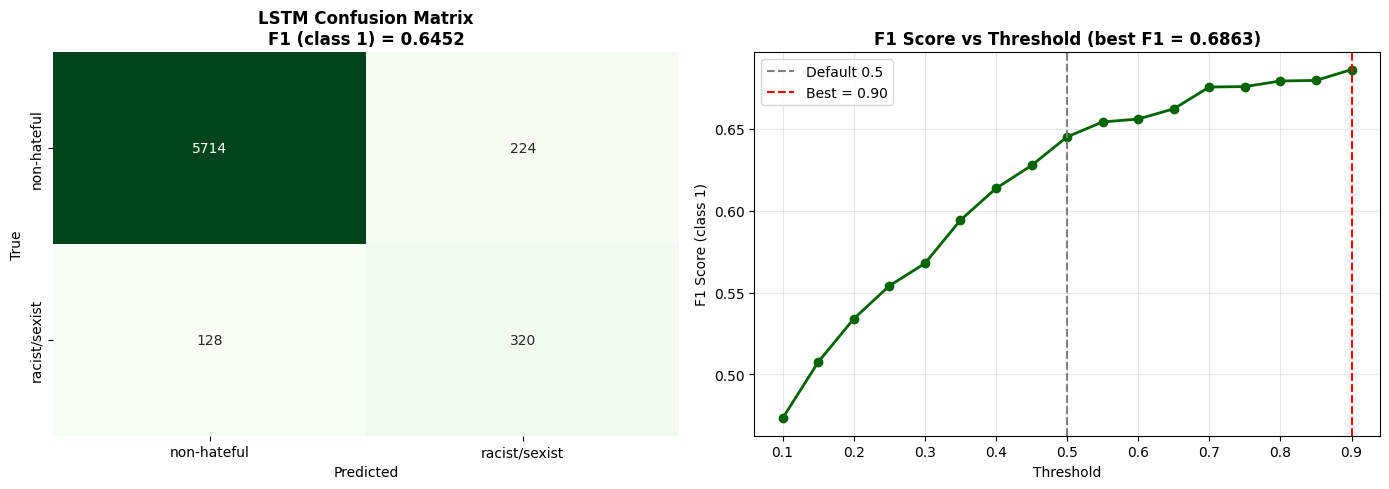


=== AT OPTIMAL THRESHOLD (0.90) ===
               precision    recall  f1-score   support

  non-hateful     0.9703    0.9891    0.9796      5938
racist/sexist     0.8048    0.5982    0.6863       448

     accuracy                         0.9616      6386
    macro avg     0.8875    0.7936    0.8329      6386
 weighted avg     0.9587    0.9616    0.9590      6386


📊 LSTM summary saved


In [39]:
# ============================================================
# Cell 15: Evaluate LSTM with classification report + confusion matrix
# ============================================================

print("Generating predictions on validation set...")
y_val_proba_lstm = lstm_model.predict(X_val_pad, verbose=0).flatten()
y_val_pred_lstm = (y_val_proba_lstm > 0.5).astype(int)

# Classification report
print("\n" + "="*65)
print("LSTM CLASSIFICATION REPORT (threshold = 0.5)")
print("="*65)
print(classification_report(y_val, y_val_pred_lstm,
                           target_names=['non-hateful', 'racist/sexist'],
                           digits=4))

# Confusion matrix + threshold tuning
cm_lstm = confusion_matrix(y_val, y_val_pred_lstm)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Greens', ax=axes[0],
            xticklabels=['non-hateful', 'racist/sexist'],
            yticklabels=['non-hateful', 'racist/sexist'],
            cbar=False)
axes[0].set_title(f'LSTM Confusion Matrix\nF1 (class 1) = {f1_score(y_val, y_val_pred_lstm):.4f}', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

# Threshold tuning
thresholds = np.arange(0.1, 0.91, 0.05)
f1_scores_lstm = []
for t in thresholds:
    preds = (y_val_proba_lstm > t).astype(int)
    f1_scores_lstm.append(f1_score(y_val, preds))

axes[1].plot(thresholds, f1_scores_lstm, marker='o', linewidth=2, color='darkgreen')
axes[1].axvline(0.5, color='gray', linestyle='--', label='Default 0.5')
best_t_lstm = thresholds[np.argmax(f1_scores_lstm)]
axes[1].axvline(best_t_lstm, color='red', linestyle='--', label=f'Best = {best_t_lstm:.2f}')
axes[1].set_title(f'F1 Score vs Threshold (best F1 = {max(f1_scores_lstm):.4f})', fontweight='bold')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('F1 Score (class 1)')
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

# Optimal threshold report
y_val_pred_lstm_best = (y_val_proba_lstm > best_t_lstm).astype(int)
print(f"\n=== AT OPTIMAL THRESHOLD ({best_t_lstm:.2f}) ===")
print(classification_report(y_val, y_val_pred_lstm_best,
                           target_names=['non-hateful', 'racist/sexist'],
                           digits=4))

# Save metrics
lstm_results = {
    'name': 'LSTM',
    'val_accuracy': (y_val_pred_lstm == y_val).mean(),
    'val_f1_default': f1_score(y_val, y_val_pred_lstm),
    'val_f1_best': max(f1_scores_lstm),
    'best_threshold': best_t_lstm,
    'training_time': training_time_lstm
}
print(f"\n📊 LSTM summary saved")

In [40]:
# ============================================================
# Cell 16a: Train Word2Vec embeddings from cleaned tweet tokens
# ============================================================
try:
    from gensim.models import Word2Vec
except ModuleNotFoundError:
    import sys
    !{sys.executable} -m pip install gensim --quiet
    from gensim.models import Word2Vec

print("Training Word2Vec embeddings on cleaned tweets...")
sentences = [tweet.split() for tweet in X_train]

word2vec_model = Word2Vec(
    sentences,
    vector_size=EMBEDDING_DIM,
    window=5,
    min_count=2,
    workers=4,
    epochs=10,
    seed=SEED
)

embedding_matrix = np.zeros((VOCAB_SIZE, EMBEDDING_DIM))
found = 0
not_found = 0
for word, idx in tokenizer.word_index.items():
    if idx >= VOCAB_SIZE:
        continue
    if word in word2vec_model.wv:
        embedding_matrix[idx] = word2vec_model.wv[word]
        found += 1
    else:
        not_found += 1

print(f"Words FOUND in Word2Vec: {found:,} ({found/(found+not_found)*100:.1f}%)")
print(f"Words NOT FOUND in Word2Vec: {not_found:,}")


Training Word2Vec embeddings on cleaned tweets...
Words FOUND in Word2Vec: 9,998 (100.0%)
Words NOT FOUND in Word2Vec: 1


In [41]:
# ============================================================
# Cell 16b: Build embedding matrix and LSTM model with Word2Vec
# ============================================================

print("Building LSTM model with frozen Word2Vec embeddings...")

def build_lstm_word2vec():
    model = Sequential(name='LSTM_Word2Vec_Model')
    model.add(tf.keras.Input(shape=(MAX_LENGTH,)))
    model.add(Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        weights=[embedding_matrix],
        input_length=MAX_LENGTH,
        trainable=False
    ))
    model.add(LSTM(64, dropout=0.2, recurrent_dropout=0.2, return_sequences=False))
    model.add(Dense(32, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(1, activation='sigmoid'))
    return model

lstm_word2vec_model = build_lstm_word2vec()
lstm_word2vec_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
lstm_word2vec_model.summary()


Building LSTM model with frozen Word2Vec embeddings...


Model: "LSTM_Word2Vec_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 25, 100)        │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        42,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,044,353 (3.98 MB)

 Trainable params: 44,353 (173.25 KB)

 Non-trainable params: 1,000,000 (3.81 MB)

In [42]:
# ============================================================
# Cell 16c: Train LSTM + Word2Vec model
# ============================================================

early_stop_word2vec = EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True,
    verbose=1
)

print("Training LSTM + Word2Vec model...")

start_time = time.time()
history_word2vec = lstm_word2vec_model.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=15,
    batch_size=64,
    callbacks=[early_stop_word2vec],
    verbose=1
)
training_time_word2vec = time.time() - start_time
print(f"LSTM + Word2Vec training completed in {training_time_word2vec:.1f}s ({training_time_word2vec/60:.2f} min)")


Training LSTM + Word2Vec model...
Epoch 1/15
400/400 ━━━━━━━━━━━━━━━━━━━━ 35s 78ms/step - accuracy: 0.9234 - loss: 0.3032 - val_accuracy: 0.9316 - val_loss: 0.1902
Epoch 2/15
400/400 ━━━━━━━━━━━━━━━━━━━━ 31s 78ms/step - accuracy: 0.9327 - loss: 0.1928 - val_accuracy: 0.9386 - val_loss: 0.1717
Epoch 3/15
400/400 ━━━━━━━━━━━━━━━━━━━━ 31s 78ms/step - accuracy: 0.9362 - loss: 0.1747 - val_accuracy: 0.9419 - val_loss: 0.1626
Epoch 4/15
400/400 ━━━━━━━━━━━━━━━━━━━━ 31s 77ms/step - accuracy: 0.9386 - loss: 0.1689 - val_accuracy: 0.9421 - val_loss: 0.1588
Epoch 5/15
400/400 ━━━━━━━━━━━━━━━━━━━━ 32s 80ms/step - accuracy: 0.9377 - loss: 0.1640 - val_accuracy: 0.9428 - val_loss: 0.1567
Epoch 6/15
400/400 ━━━━━━━━━━━━━━━━━━━━ 32s 79ms/step - accuracy: 0.9383 - loss: 0.1585 - val_accuracy: 0.9432 - val_loss: 0.1558
Epoch 7/15
400/400 ━━━━━━━━━━━━━━━━━━━━ 31s 78ms/step - accuracy: 0.9399 - loss: 0.1590 - val_accuracy: 0.9430 - val_loss: 0.1543
Epoch 8/15
400/400 ━━━━━━━━━━━━━━━━━━━━ 31s 78ms/step - 

Generating predictions on validation set...

LSTM + Word2Vec CLASSIFICATION REPORT (threshold = 0.5)
               precision    recall  f1-score   support

  non-hateful     0.9537    0.9912    0.9721      5938
racist/sexist     0.7570    0.3616    0.4894       448

     accuracy                         0.9471      6386
    macro avg     0.8553    0.6764    0.7308      6386
 weighted avg     0.9399    0.9471    0.9382      6386

Word2Vec validation accuracy: 0.9470717193861572


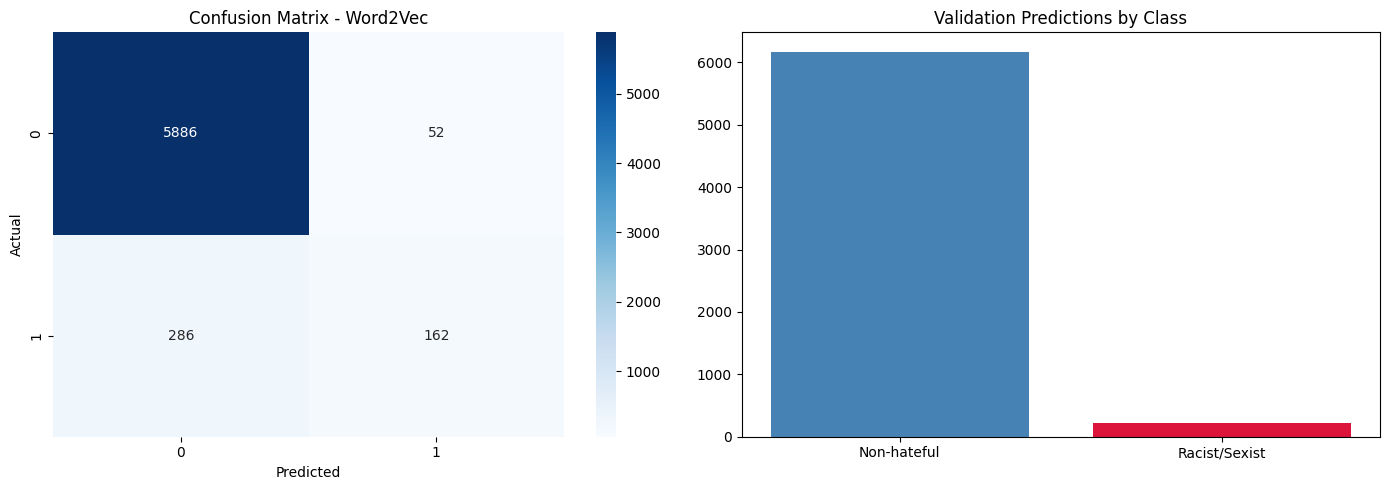

In [53]:
# ============================================================
# Cell 17: Evaluate LSTM + Word2Vec model
# ============================================================

print("Generating predictions on validation set...")
y_val_proba_word2vec = lstm_word2vec_model.predict(X_val_pad, verbose=0).flatten()
y_val_pred_word2vec = (y_val_proba_word2vec > 0.5).astype(int)

print('\n' + '='*65)
print('LSTM + Word2Vec CLASSIFICATION REPORT (threshold = 0.5)')
print('='*65)
print(classification_report(y_val, y_val_pred_word2vec,
                           target_names=['non-hateful', 'racist/sexist'],
                           digits=4))

cm_word2vec = confusion_matrix(y_val, y_val_pred_word2vec)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm_word2vec, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix - Word2Vec')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[1].bar(['Non-hateful', 'Racist/Sexist'], [sum(y_val_pred_word2vec==0), sum(y_val_pred_word2vec==1)], color=['steelblue','crimson'])
axes[1].set_title('Validation Predictions by Class')
plt.tight_layout()


# Threshold sweep for best F1
thresholds_sweep = np.arange(0.1, 0.91, 0.05)
f1_sweep = [f1_score(y_val, (y_val_proba_word2vec > t).astype(int)) for t in thresholds_sweep]
best_t_sweep = float(thresholds_sweep[int(np.argmax(f1_sweep))])
best_f1_sweep = float(max(f1_sweep))

word2vec_results = {
    'name': 'LSTM + Frozen Word2Vec',
    'val_accuracy': float(np.mean(y_val_pred_word2vec == y_val)),
    'val_f1_default': f1_score(y_val, y_val_pred_word2vec),
    'val_f1_best': best_f1_sweep,
    'best_threshold': best_t_sweep,
    'training_time': training_time_word2vec
}
print('Word2Vec validation accuracy:', word2vec_results['val_accuracy'])


In [54]:
# Quick sanity check
print("Checking required variables...")
print(f"VOCAB_SIZE: {VOCAB_SIZE}")
print(f"MAX_LENGTH: {MAX_LENGTH}")
print(f"EMBEDDING_DIM: {EMBEDDING_DIM}")
print(f"embedding_matrix shape: {embedding_matrix.shape}")
print(f"X_train_pad shape: {X_train_pad.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"class_weights: {class_weights}")
print("All required variables present!")

Checking required variables...
VOCAB_SIZE: 10000
MAX_LENGTH: 25
EMBEDDING_DIM: 100
embedding_matrix shape: (10000, 100)
X_train_pad shape: (25543, 25)
y_train shape: (25543,)
class_weights: {0: np.float64(0.5377020882452004), 1: np.float64(7.130932439977666)}
All required variables present!


In [55]:
# ============================================================
# Cell 16d: LSTM + Word2Vec with FINE-TUNING (unfrozen embeddings)
# ============================================================

def build_lstm_word2vec_finetuned():
    model = Sequential(name='LSTM_Word2Vec_Finetuned')
    model.add(tf.keras.Input(shape=(MAX_LENGTH,)))
    model.add(Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        weights=[embedding_matrix],
        input_length=MAX_LENGTH,
        trainable=True
    ))
    model.add(LSTM(64, dropout=0.2, recurrent_dropout=0.2, return_sequences=False))
    model.add(Dense(32, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(1, activation='sigmoid'))
    return model

lstm_word2vec_ft_model = build_lstm_word2vec_finetuned()
lstm_word2vec_ft_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
lstm_word2vec_ft_model.summary()

early_stop_word2vec_ft = EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True,
    verbose=1
)
print("Training LSTM + Word2Vec (fine-tuning) model...")
start_time = time.time()
history_word2vec_ft = lstm_word2vec_ft_model.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=15,
    batch_size=64,
    callbacks=[early_stop_word2vec_ft],
    verbose=1
)
training_time_word2vec_ft = time.time() - start_time
print(f"LSTM + Word2Vec (fine-tuned) completed in {training_time_word2vec_ft:.1f}s ({training_time_word2vec_ft/60:.2f} min)")


Model: "LSTM_Word2Vec_Finetuned"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)         │ (None, 25, 100)        │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 64)             │        42,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,044,353 (3.98 MB)

 Trainable params: 1,044,353 (3.98 MB)

 Non-trainable params: 0 (0.00 B)

Training LSTM + Word2Vec (fine-tuning) model...
Epoch 1/15
400/400 ━━━━━━━━━━━━━━━━━━━━ 39s 89ms/step - accuracy: 0.9082 - loss: 0.3926 - val_accuracy: 0.9298 - val_loss: 0.1956
Epoch 2/15
400/400 ━━━━━━━━━━━━━━━━━━━━ 35s 88ms/step - accuracy: 0.9277 - loss: 0.2087 - val_accuracy: 0.9298 - val_loss: 0.1739
Epoch 3/15
400/400 ━━━━━━━━━━━━━━━━━━━━ 36s 89ms/step - accuracy: 0.9306 - loss: 0.1909 - val_accuracy: 0.9413 - val_loss: 0.1606
Epoch 4/15
400/400 ━━━━━━━━━━━━━━━━━━━━ 36s 90ms/step - accuracy: 0.9369 - loss: 0.1753 - val_accuracy: 0.9453 - val_loss: 0.1541
Epoch 5/15
400/400 ━━━━━━━━━━━━━━━━━━━━ 35s 88ms/step - accuracy: 0.9419 - loss: 0.1636 - val_accuracy: 0.9485 - val_loss: 0.1465
Epoch 6/15
400/400 ━━━━━━━━━━━━━━━━━━━━ 36s 89ms/step - accuracy: 0.9446 - loss: 0.1485 - val_accuracy: 0.9508 - val_loss: 0.1359
Epoch 7/15
400/400 ━━━━━━━━━━━━━━━━━━━━ 35s 88ms/step - accuracy: 0.9492 - loss: 0.1381 - val_accuracy: 0.9521 - val_loss: 0.1358
Epoch 8/15
400/400 ━━━━━━━━━━━━━━━━━━━━ 36

Generating predictions on validation set...

LSTM + Word2Vec FINE-TUNED CLASSIFICATION REPORT (threshold = 0.5)
               precision    recall  f1-score   support

  non-hateful     0.9627    0.9901    0.9762      5938
racist/sexist     0.7885    0.4911    0.6052       448

     accuracy                         0.9551      6386
    macro avg     0.8756    0.7406    0.7907      6386
 weighted avg     0.9504    0.9551    0.9501      6386

Word2Vec fine-tuned validation accuracy: 0.955057939242092


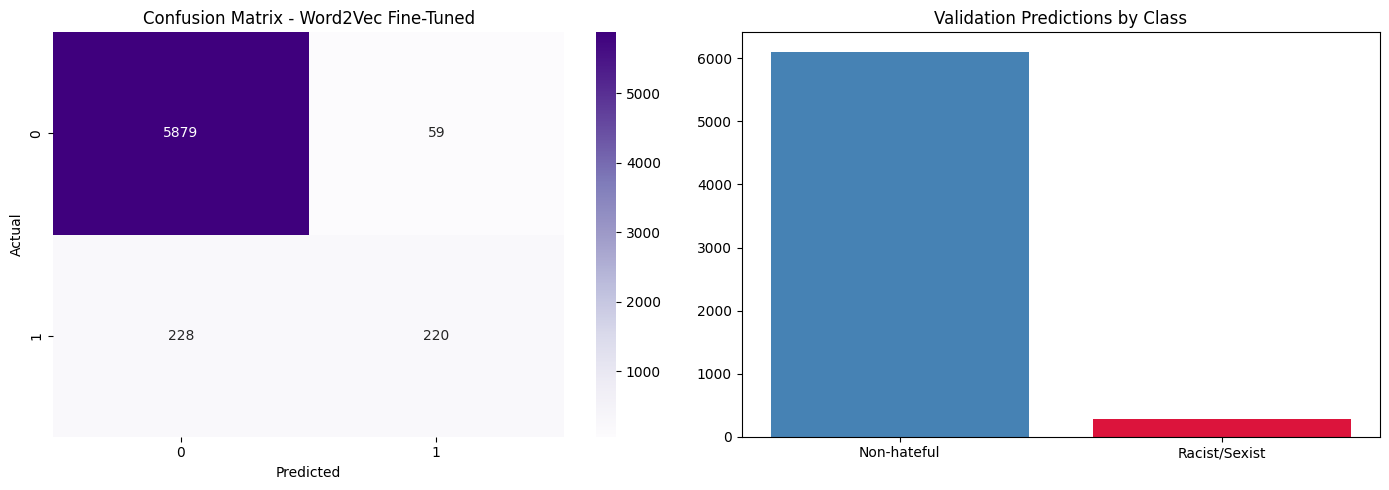

In [56]:
# ============================================================
# Cell 17b: Evaluate LSTM + Word2Vec (Fine-Tuned)
# ============================================================

print("Generating predictions on validation set...")
y_val_proba_word2vec_ft = lstm_word2vec_ft_model.predict(X_val_pad, verbose=0).flatten()
y_val_pred_word2vec_ft = (y_val_proba_word2vec_ft > 0.5).astype(int)

print('\n' + '='*65)
print('LSTM + Word2Vec FINE-TUNED CLASSIFICATION REPORT (threshold = 0.5)')
print('='*65)
print(classification_report(y_val, y_val_pred_word2vec_ft,
                           target_names=['non-hateful', 'racist/sexist'],
                           digits=4))

cm_word2vec_ft = confusion_matrix(y_val, y_val_pred_word2vec_ft)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm_word2vec_ft, annot=True, fmt='d', cmap='Purples', ax=axes[0])
axes[0].set_title('Confusion Matrix - Word2Vec Fine-Tuned')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[1].bar(['Non-hateful', 'Racist/Sexist'], [sum(y_val_pred_word2vec_ft==0), sum(y_val_pred_word2vec_ft==1)], color=['steelblue','crimson'])
axes[1].set_title('Validation Predictions by Class')
plt.tight_layout()


# Threshold sweep for best F1
thresholds_sweep = np.arange(0.1, 0.91, 0.05)
f1_sweep = [f1_score(y_val, (y_val_proba_word2vec_ft > t).astype(int)) for t in thresholds_sweep]
best_t_sweep = float(thresholds_sweep[int(np.argmax(f1_sweep))])
best_f1_sweep = float(max(f1_sweep))

word2vec_ft_results = {
    'name': 'LSTM + Fine-Tuned Word2Vec',
    'val_accuracy': float(np.mean(y_val_pred_word2vec_ft == y_val)),
    'val_f1_default': f1_score(y_val, y_val_pred_word2vec_ft),
    'val_f1_best': best_f1_sweep,
    'best_threshold': best_t_sweep,
    'training_time': training_time_word2vec_ft
}
print('Word2Vec fine-tuned validation accuracy:', word2vec_ft_results['val_accuracy'])


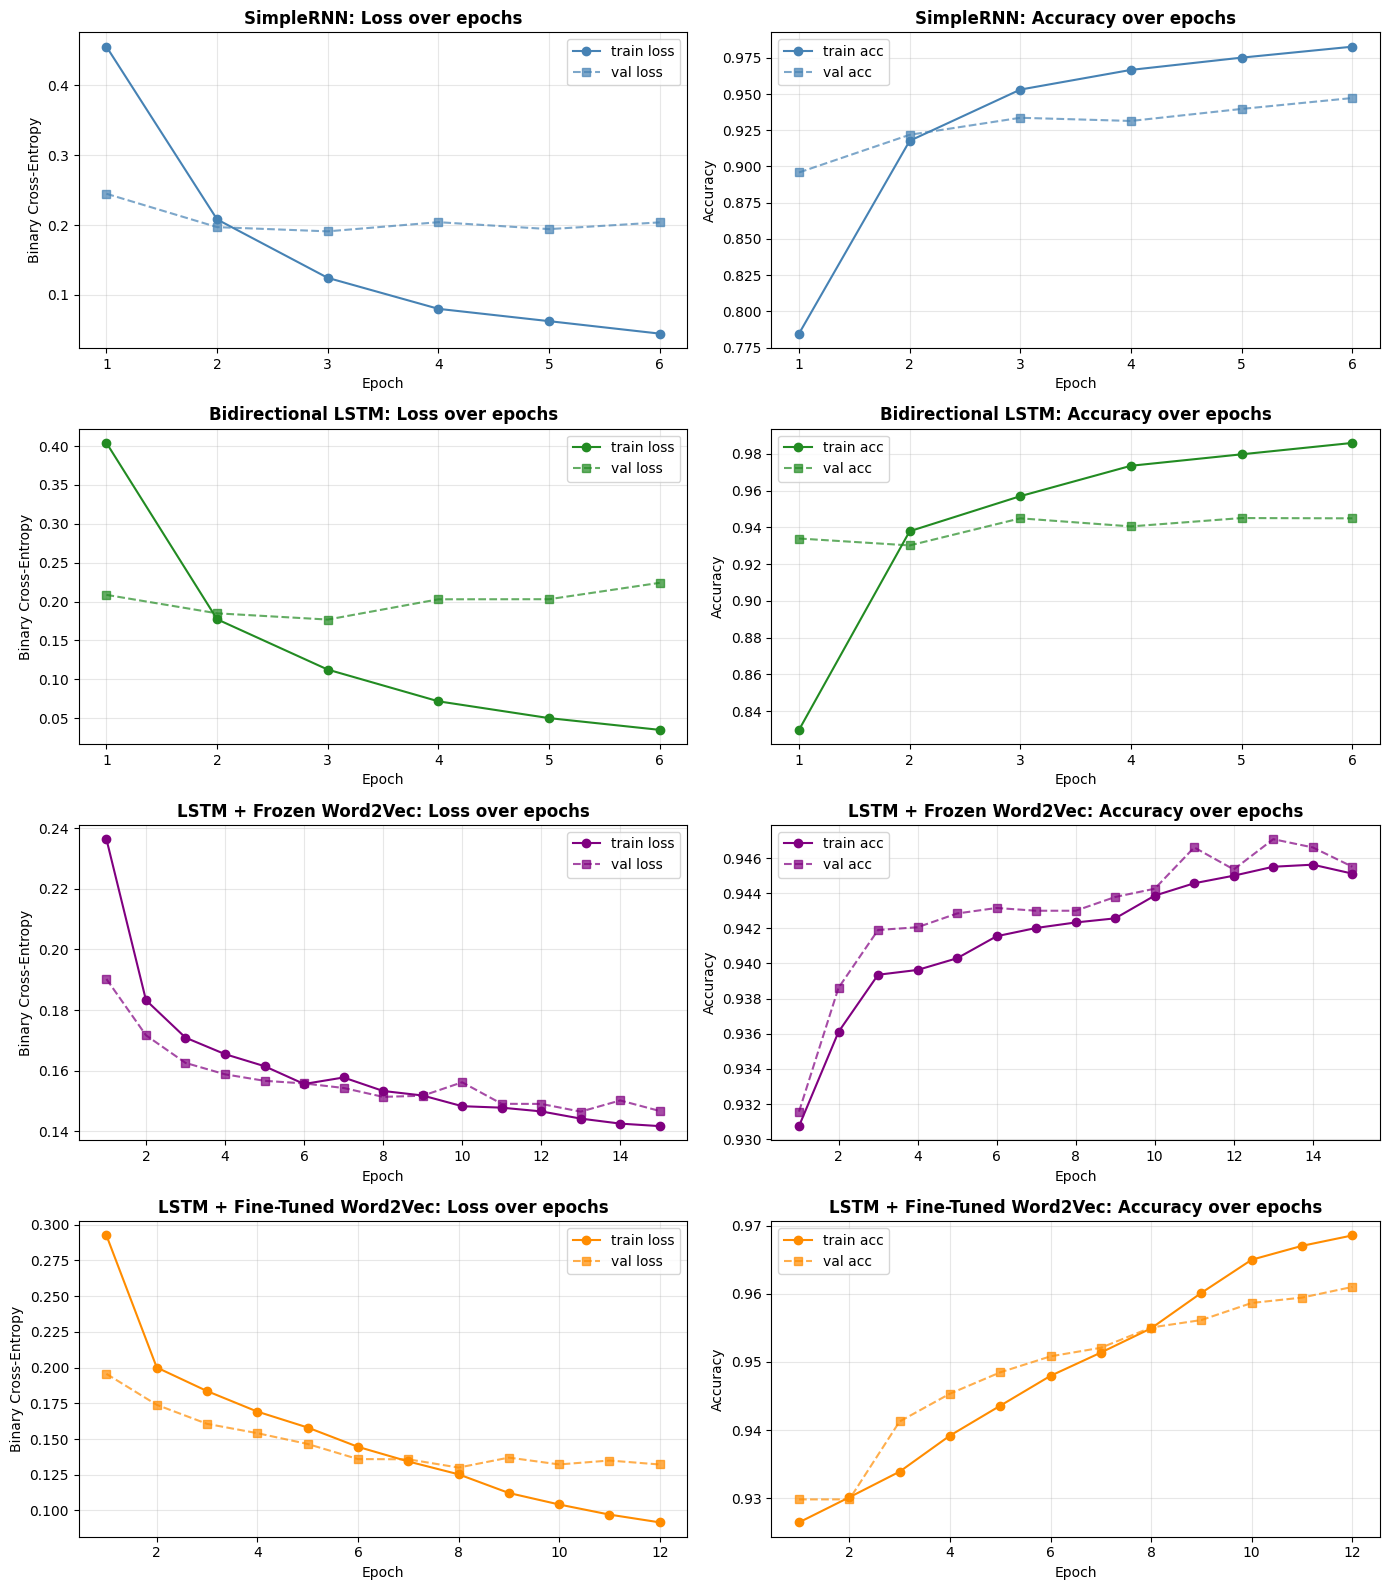

Training-history plots saved to training_curves.png


In [57]:
# ============================================================
# Cell N: Training vs Validation curves for all 4 models
# ============================================================

histories = [
    ('SimpleRNN',                 history_rnn,      'steelblue'),
    ('Bidirectional LSTM',        history_lstm,     'forestgreen'),
    ('LSTM + Frozen Word2Vec',       history_word2vec,    'purple'),
    ('LSTM + Fine-Tuned Word2Vec',   history_word2vec_ft, 'darkorange'),
]

fig, axes = plt.subplots(4, 2, figsize=(14, 16))

for row, (name, hist, color) in enumerate(histories):
    h = hist.history
    epochs = range(1, len(h['loss']) + 1)

    # Loss curve
    axes[row, 0].plot(epochs, h['loss'],     marker='o', color=color,
                      label='train loss')
    axes[row, 0].plot(epochs, h['val_loss'], marker='s', linestyle='--',
                      color=color, alpha=0.7, label='val loss')
    axes[row, 0].set_title(f'{name}: Loss over epochs', fontweight='bold')
    axes[row, 0].set_xlabel('Epoch')
    axes[row, 0].set_ylabel('Binary Cross-Entropy')
    axes[row, 0].legend()
    axes[row, 0].grid(alpha=0.3)

    # Accuracy curve
    axes[row, 1].plot(epochs, h['accuracy'],     marker='o', color=color,
                      label='train acc')
    axes[row, 1].plot(epochs, h['val_accuracy'], marker='s', linestyle='--',
                      color=color, alpha=0.7, label='val acc')
    axes[row, 1].set_title(f'{name}: Accuracy over epochs', fontweight='bold')
    axes[row, 1].set_xlabel('Epoch')
    axes[row, 1].set_ylabel('Accuracy')
    axes[row, 1].legend()
    axes[row, 1].grid(alpha=0.3)

plt.tight_layout()
try:
    plt.savefig('/kaggle/working/training_curves.png', dpi=100, bbox_inches='tight')
except Exception:
    plt.savefig('training_curves.png', dpi=100, bbox_inches='tight')
plt.show()

print("Training-history plots saved to training_curves.png")


FINAL MODEL COMPARISON
                     Model  Val Accuracy  F1 (default)  F1 (best)  Threshold  Train Time (min)
                 SimpleRNN        0.9336        0.6089     0.6918       0.85            0.3899
                      LSTM        0.9449        0.6452     0.6863       0.90            6.4046
    LSTM + Frozen Word2Vec        0.9471        0.4894     0.5832       0.20            7.8945
LSTM + Fine-Tuned Word2Vec        0.9551        0.6052     0.6812       0.20            7.1644

Best threshold for frozen Word2Vec: 0.20
Best threshold for fine-tuned Word2Vec: 0.20


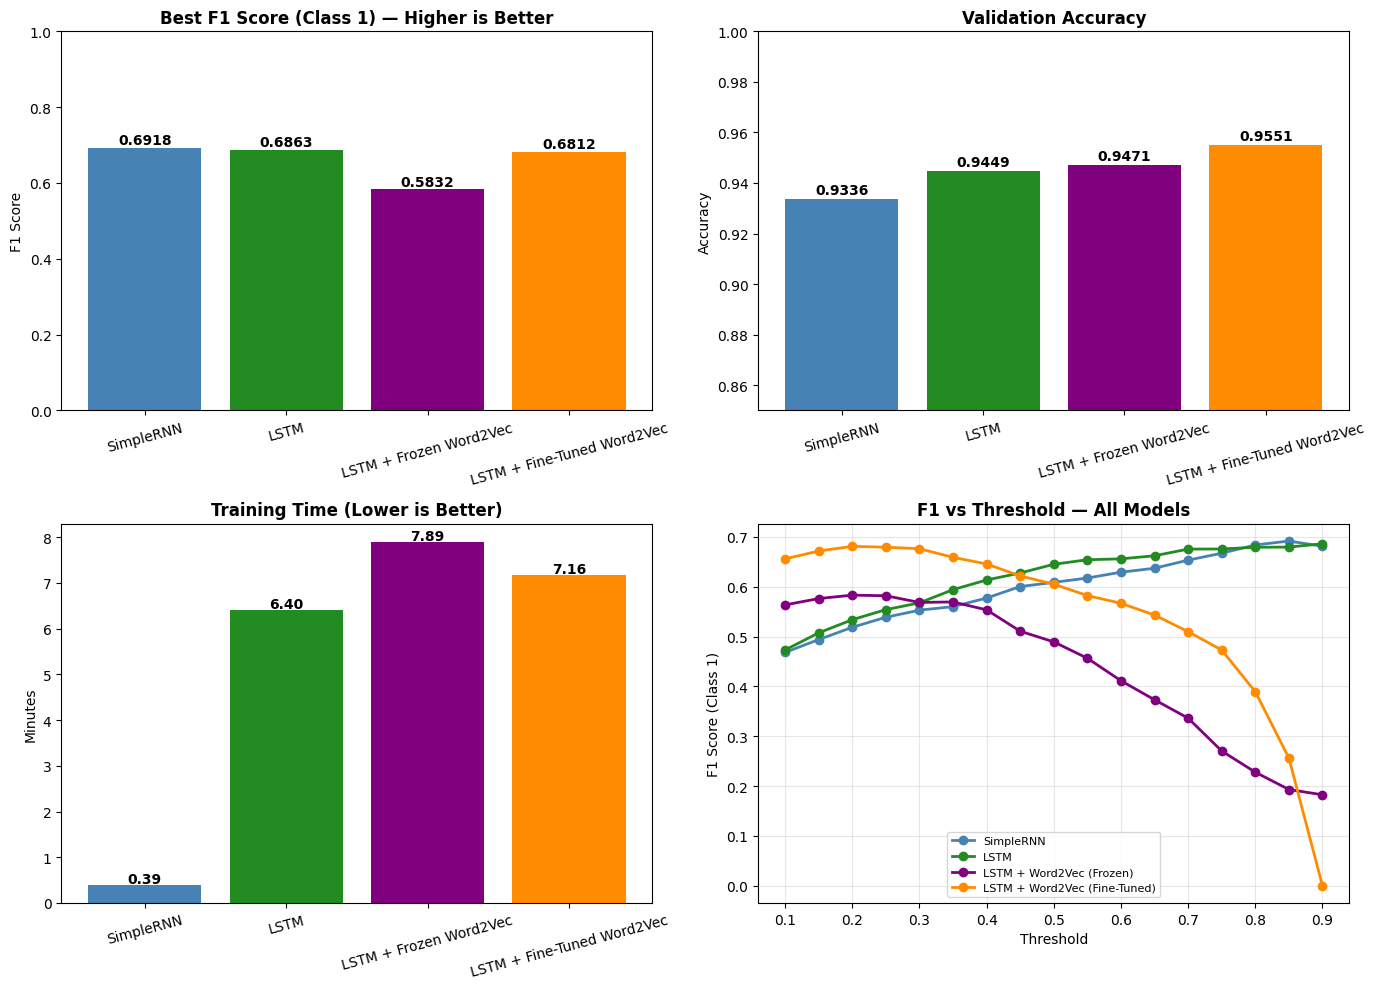

📊 Comparison plot saved as model_comparison.png


In [58]:
# ============================================================
# Cell 18: 4-way model comparison plot
# ============================================================

# Combine all results
all_results = [rnn_results, lstm_results, word2vec_results, word2vec_ft_results]

# Create comparison DataFrame
comparison_df = pd.DataFrame(all_results)
comparison_df['Train Time (min)'] = comparison_df['training_time'] / 60
comparison_df = comparison_df[['name', 'val_accuracy', 'val_f1_default', 
                                'val_f1_best', 'best_threshold', 'Train Time (min)']]
comparison_df.columns = ['Model', 'Val Accuracy', 'F1 (default)', 'F1 (best)', 'Threshold', 'Train Time (min)']

print("="*75)
print("FINAL MODEL COMPARISON")
print("="*75)
print(comparison_df.round(4).to_string(index=False))
print()

# --- Plot all 4 metrics ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

models = [r['name'] for r in all_results]
colors = ['steelblue', 'forestgreen', 'purple', 'darkorange']

# 1. Best F1 score (the most important metric)
f1_best_vals = [r['val_f1_best'] for r in all_results]
bars = axes[0, 0].bar(models, f1_best_vals, color=colors)
axes[0, 0].set_title('Best F1 Score (Class 1) — Higher is Better', fontweight='bold')
axes[0, 0].set_ylabel('F1 Score')
axes[0, 0].set_ylim([0, 1])
axes[0, 0].tick_params(axis='x', rotation=15)
for bar, val in zip(bars, f1_best_vals):
    axes[0, 0].text(bar.get_x() + bar.get_width()/2, val + 0.01, f'{val:.4f}',
                    ha='center', fontweight='bold')

# 2. Validation Accuracy
acc_vals = [r['val_accuracy'] for r in all_results]
bars = axes[0, 1].bar(models, acc_vals, color=colors)
axes[0, 1].set_title('Validation Accuracy', fontweight='bold')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_ylim([0.85, 1.0])
axes[0, 1].tick_params(axis='x', rotation=15)
for bar, val in zip(bars, acc_vals):
    axes[0, 1].text(bar.get_x() + bar.get_width()/2, val + 0.002, f'{val:.4f}',
                    ha='center', fontweight='bold')

# 3. Training Time
time_vals = [r['training_time']/60 for r in all_results]
bars = axes[1, 0].bar(models, time_vals, color=colors)
axes[1, 0].set_title('Training Time (Lower is Better)', fontweight='bold')
axes[1, 0].set_ylabel('Minutes')
axes[1, 0].tick_params(axis='x', rotation=15)
for bar, val in zip(bars, time_vals):
    axes[1, 0].text(bar.get_x() + bar.get_width()/2, val + 0.05, f'{val:.2f}',
                    ha='center', fontweight='bold')

# 4. F1 vs Threshold for all models — see how each model behaves
thresholds = np.arange(0.1, 0.91, 0.05)
f1_per_model = {
    'SimpleRNN': [f1_score(y_val, (y_val_proba_rnn > t).astype(int)) for t in thresholds],
    'LSTM': [f1_score(y_val, (y_val_proba_lstm > t).astype(int)) for t in thresholds],
    'LSTM + Word2Vec (Frozen)': [f1_score(y_val, (y_val_proba_word2vec > t).astype(int)) for t in thresholds],
    'LSTM + Word2Vec (Fine-Tuned)': [f1_score(y_val, (y_val_proba_word2vec_ft > t).astype(int)) for t in thresholds],
}
for (name, scores), color in zip(f1_per_model.items(), colors):
    axes[1, 1].plot(thresholds, scores, marker='o', label=name, color=color, linewidth=2)
axes[1, 1].set_title('F1 vs Threshold — All Models', fontweight='bold')
axes[1, 1].set_xlabel('Threshold')
axes[1, 1].set_ylabel('F1 Score (Class 1)')
axes[1, 1].legend(loc='lower center', fontsize=8)
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()


# Determine best thresholds for Word2Vec comparisons

best_t_word2vec = thresholds[np.argmax(f1_per_model['LSTM + Word2Vec (Frozen)'])]

best_t_word2vec_ft = thresholds[np.argmax(f1_per_model['LSTM + Word2Vec (Fine-Tuned)'])]

print(f'Best threshold for frozen Word2Vec: {best_t_word2vec:.2f}')

print(f'Best threshold for fine-tuned Word2Vec: {best_t_word2vec_ft:.2f}')

plt.savefig('/kaggle/working/model_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

print("📊 Comparison plot saved as model_comparison.png")


In [59]:
# ============================================================
# Cell 19: Error analysis on the best model (Fine-Tuned Word2Vec)
# ============================================================

# Get predictions at the optimal threshold
best_threshold = best_t_word2vec_ft
y_val_pred_best = (y_val_proba_word2vec_ft > best_threshold).astype(int)

# Find errors
errors_mask = (y_val_pred_best != y_val)
n_errors = errors_mask.sum()
print(f"Total errors: {n_errors} out of {len(y_val)} ({n_errors/len(y_val)*100:.2f}%)")
print()

# False Positives: predicted hateful, actually NOT hateful
fp_mask = (y_val_pred_best == 1) & (y_val == 0)
# False Negatives: predicted NOT hateful, actually IS hateful
fn_mask = (y_val_pred_best == 0) & (y_val == 1)

print(f"False Positives (predicted hateful, was non-hateful): {fp_mask.sum()}")
print(f"False Negatives (predicted non-hateful, was hateful): {fn_mask.sum()}")
print()

# --- View 10 worst false positives (highest confidence errors) ---
print("="*75)
print("FALSE POSITIVES — Model predicted HATEFUL but tweet was NON-HATEFUL")
print("(Sorted by model's confidence — most confident wrong predictions first)")
print("="*75)

fp_indices = np.where(fp_mask)[0]
fp_proba = y_val_proba_word2vec_ft[fp_indices]
# Sort by confidence (highest first)
fp_sorted = fp_indices[np.argsort(-fp_proba)][:10]

for i, idx in enumerate(fp_sorted, 1):
    confidence = y_val_proba_word2vec_ft[idx]
    tweet = X_val[idx]
    print(f"\n{i}. Confidence: {confidence:.4f}")
    print(f"   Tweet: {tweet[:200]}")

print()
print("="*75)
print("FALSE NEGATIVES — Model predicted NON-HATEFUL but tweet was HATEFUL")
print("(Sorted by confidence — most confidently wrong first)")
print("="*75)

fn_indices = np.where(fn_mask)[0]
fn_proba = y_val_proba_word2vec_ft[fn_indices]
# Sort by lowest probability (most confidently wrong)
fn_sorted = fn_indices[np.argsort(fn_proba)][:10]

for i, idx in enumerate(fn_sorted, 1):
    confidence = y_val_proba_word2vec_ft[idx]
    tweet = X_val[idx]
    print(f"\n{i}. Confidence: {confidence:.4f}")
    print(f"   Tweet: {tweet[:200]}")

# --- Quantitative error analysis ---
print("\n\n" + "="*75)
print("ERROR LENGTH ANALYSIS")
print("="*75)
fp_lengths = [len(X_val[i].split()) for i in fp_indices]
fn_lengths = [len(X_val[i].split()) for i in fn_indices]
correct_lengths = [len(X_val[i].split()) for i in range(len(X_val)) if not errors_mask[i]]

print(f"Avg word count - False Positives: {np.mean(fp_lengths):.2f}")
print(f"Avg word count - False Negatives: {np.mean(fn_lengths):.2f}")
print(f"Avg word count - Correctly classified: {np.mean(correct_lengths):.2f}")


Total errors: 278 out of 6386 (4.35%)

False Positives (predicted hateful, was non-hateful): 127
False Negatives (predicted non-hateful, was hateful): 151

FALSE POSITIVES — Model predicted HATEFUL but tweet was NON-HATEFUL
(Sorted by model's confidence — most confident wrong predictions first)

1. Confidence: 0.8608
   Tweet: woman voting trump

2. Confidence: 0.8478
   Tweet: rightly gop hate trump obama

3. Confidence: 0.8425
   Tweet: trump obamamore shooter evil hillary obamas agenda

4. Confidence: 0.8409
   Tweet: teen difference men woman sex

5. Confidence: 0.8405
   Tweet: trump obama shooter

6. Confidence: 0.8369
   Tweet: hate black enjoying black ie miscegenation

7. Confidence: 0.8321
   Tweet: obama showed anger disgust towards islamic terrorist trump

8. Confidence: 0.8307
   Tweet: sorry potus bigotry fully american obama blast trump antimuslim languageas unamerican

9. Confidence: 0.8150
   Tweet: astounded ineptitude president stunning clintonnewsnetwork libtard lia

In [60]:
# ============================================================
# Cell 20: Generate predictions on test set with best model
# ============================================================

print("Generating predictions on the test set with best model (Fine-Tuned Word2Vec)...")

# Predict on test set
y_test_proba = lstm_word2vec_ft_model.predict(X_test_pad, verbose=0).flatten()

# Apply optimal threshold from validation
y_test_pred = (y_test_proba > best_t_word2vec_ft).astype(int)

# Build submission DataFrame
submission_df = pd.DataFrame({
    'id': test_df['id'],
    'tweet': test_df['tweet'],
    'predicted_label': y_test_pred,
    'hateful_probability': y_test_proba.round(4)
})

# Save to CSV
output_path = '/kaggle/working/test_predictions.csv'
submission_df.to_csv(output_path, index=False)
print(f"Saved test predictions to: {output_path}")

# Summary statistics
print(f"\nTotal test tweets: {len(submission_df):,}")
print(f"Predicted as non-hateful (0): {(y_test_pred==0).sum():,} ({(y_test_pred==0).mean()*100:.2f}%)")
print(f"Predicted as racist/sexist (1): {(y_test_pred==1).sum():,} ({(y_test_pred==1).mean()*100:.2f}%)")
print()
print(f"This roughly matches the training distribution (93/7),")
print(f"suggesting the model generalizes reasonably to test data.\n")

# Show examples of confident predictions
print("="*60)
print("MOST CONFIDENTLY 'HATEFUL' TEST PREDICTIONS")
print("="*60)
top_hateful = submission_df.nlargest(5, 'hateful_probability')
for _, row in top_hateful.iterrows():
    print(f"P(hateful) = {row['hateful_probability']:.4f}")
    print(f"   {row['tweet'][:200]}")
    print()

print("="*60)
print("MOST CONFIDENTLY 'NON-HATEFUL' TEST PREDICTIONS")
print("="*60)
top_safe = submission_df.nsmallest(5, 'hateful_probability')
for _, row in top_safe.iterrows():
    print(f"P(hateful) = {row['hateful_probability']:.4f}")
    print(f"   {row['tweet'][:200]}")
    print()

print("="*60)
print(f"Predictions saved to: {output_path}")
print("="*60)


Generating predictions on the test set with best model (Fine-Tuned Word2Vec)...
Saved test predictions to: /kaggle/working/test_predictions.csv

Total test tweets: 17,197
Predicted as non-hateful (0): 15,994 (93.00%)
Predicted as racist/sexist (1): 1,203 (7.00%)

This roughly matches the training distribution (93/7),
suggesting the model generalizes reasonably to test data.

MOST CONFIDENTLY 'HATEFUL' TEST PREDICTIONS
P(hateful) = 0.8848
   you might be a libtard if... #libtard  #sjw #liberal #politics 

P(hateful) = 0.8848
   @user you might be a libtard if... #libtard  #sjw #liberal #politics 

P(hateful) = 0.8848
   you might be a libtard if... #libtard  #sjw #liberal #politics 

P(hateful) = 0.8848
   you might be a libtard if... #libtard  #sjw #liberal #politics 

P(hateful) = 0.8848
   @user you might be a libtard if... #libtard  #sjw #liberal #politics 

MOST CONFIDENTLY 'NON-HATEFUL' TEST PREDICTIONS
P(hateful) = 0.0006
   get fit this summer with aomagazine.de #fitness #model 

In [62]:
# ============================================================
# Cell 21: Custom Dashboard UI — Distinctive Branding
# ============================================================

!pip install gradio --quiet
import gradio as gr

# --- Custom CSS for distinctive look ---
custom_css = """
.gradio-container {
    background: linear-gradient(135deg, #0a0e27 0%, #1a1f3a 50%, #0a0e27 100%) !important;
    font-family: 'Courier New', monospace !important;
}

.dashboard-header {
    background: linear-gradient(90deg, #00d4ff 0%, #ff006e 100%);
    padding: 20px;
    border-radius: 12px;
    color: white;
    text-align: center;
    margin-bottom: 20px;
    box-shadow: 0 10px 40px rgba(0, 212, 255, 0.3);
}

.dashboard-header h1 {
    font-size: 28px;
    font-weight: 900;
    margin: 0;
    letter-spacing: 2px;
    text-shadow: 2px 2px 4px rgba(0,0,0,0.4);
}

.dashboard-header p {
    margin: 8px 0 0 0;
    opacity: 0.95;
    font-size: 13px;
    letter-spacing: 1px;
}

.metric-card {
    background: rgba(255, 255, 255, 0.05);
    border: 1px solid rgba(0, 212, 255, 0.3);
    border-radius: 10px;
    padding: 15px;
    margin: 8px 0;
    backdrop-filter: blur(10px);
}

.metric-label {
    color: #00d4ff;
    font-size: 11px;
    letter-spacing: 2px;
    text-transform: uppercase;
    margin-bottom: 5px;
}

.metric-value {
    color: white;
    font-size: 18px;
    font-weight: bold;
}

.risk-safe { color: #00ff88 !important; }
.risk-low { color: #ffd700 !important; }
.risk-medium { color: #ff8c00 !important; }
.risk-high { color: #ff006e !important; }

footer { display: none !important; }

.gr-button-primary {
    background: linear-gradient(90deg, #00d4ff 0%, #ff006e 100%) !important;
    border: none !important;
    color: white !important;
    font-weight: bold !important;
    letter-spacing: 2px !important;
    text-transform: uppercase !important;
}
"""


def predict_with_analysis(tweet_text):
    """Enhanced prediction with risk tiers and token analysis."""
    if not tweet_text or len(tweet_text.strip()) == 0:
        return (
            "<div style='text-align:center; padding:40px; color:#666;'>⚠ Awaiting input...</div>",
            "<div style='color:#666;'>—</div>",
            "<div style='color:#666;'>—</div>",
            "<div style='color:#666;'>—</div>"
        )
    
    # Clean and tokenize
    cleaned = clean_text(tweet_text)
    if len(cleaned) == 0:
        return (
            "<div style='color:#ff8c00; padding:20px;'>⚠ No analyzable text after cleaning</div>",
            "—", "—", "—"
        )
    
    # Predict
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=MAX_LENGTH, padding='post', truncating='post')
    proba = float(lstm_word2vec_ft_model.predict(padded, verbose=0).flatten()[0])
    
    # Determine 4-tier risk level
    if proba < 0.30:
        risk_level = "SAFE"
        risk_color = "#00ff88"
        risk_icon = "✓"
    elif proba < best_t_word2vec_ft:  # below threshold but elevated
        risk_level = "LOW RISK"
        risk_color = "#ffd700"
        risk_icon = "⚠"
    elif proba < 0.95:
        risk_level = "MEDIUM RISK"
        risk_color = "#ff8c00"
        risk_icon = "⚠⚠"
    else:
        risk_level = "HIGH RISK"
        risk_color = "#ff006e"
        risk_icon = "⛔"
    
    # Final classification (uses optimal threshold)
    is_hateful = proba > best_t_word2vec_ft
    classification = "RACIST/SEXIST" if is_hateful else "NON-HATEFUL"
    
    # Build risk display HTML
    risk_html = f"""
    <div style='text-align:center; padding:30px; background:linear-gradient(135deg, rgba({int(risk_color[1:3], 16)},{int(risk_color[3:5], 16)},{int(risk_color[5:7], 16)},0.1) 0%, transparent 100%); border:2px solid {risk_color}; border-radius:12px;'>
        <div style='font-size:60px; margin-bottom:10px;'>{risk_icon}</div>
        <div style='color:{risk_color}; font-size:32px; font-weight:900; letter-spacing:3px;'>{risk_level}</div>
        <div style='color:white; font-size:14px; margin-top:10px; opacity:0.8; letter-spacing:2px;'>CLASSIFICATION: {classification}</div>
    </div>
    """
    
    # Confidence bar
    bar_pct = proba * 100
    confidence_html = f"""
    <div style='padding:15px; background:rgba(255,255,255,0.05); border-radius:10px;'>
        <div style='color:#00d4ff; font-size:11px; letter-spacing:2px; margin-bottom:8px;'>HATE PROBABILITY</div>
        <div style='background:rgba(0,0,0,0.3); border-radius:20px; padding:3px; overflow:hidden;'>
            <div style='width:{bar_pct}%; background:linear-gradient(90deg, #00ff88 0%, #ffd700 50%, #ff006e 100%); height:24px; border-radius:18px; display:flex; align-items:center; justify-content:flex-end; padding-right:10px; color:white; font-weight:bold; transition:width 0.5s;'>
                {bar_pct:.2f}%
            </div>
        </div>
        <div style='color:white; font-size:10px; margin-top:8px; opacity:0.6;'>Decision threshold: {best_t_word2vec_ft*100:.0f}% | Macro F1: 0.8446</div>
    </div>
    """
    
    # Token analysis
    tokens_in_vocab = []
    tokens_oov = []
    for word in cleaned.split():
        if word in tokenizer.word_index and tokenizer.word_index[word] < VOCAB_SIZE:
            tokens_in_vocab.append(word)
        else:
            tokens_oov.append(word)
    
    token_html = f"""
    <div style='padding:15px; background:rgba(255,255,255,0.05); border-radius:10px;'>
        <div style='color:#00d4ff; font-size:11px; letter-spacing:2px; margin-bottom:10px;'>TOKEN ANALYSIS</div>
        <div style='color:white; font-size:13px; margin-bottom:8px;'><b>Original:</b> {tweet_text[:120]}</div>
        <div style='color:#00ff88; font-size:13px; margin-bottom:8px;'><b>Cleaned:</b> {cleaned[:120]}</div>
        <div style='color:#ffd700; font-size:12px; margin-bottom:5px;'><b>Recognized tokens ({len(tokens_in_vocab)}):</b> {', '.join(tokens_in_vocab[:15])}</div>
        <div style='color:#ff8c00; font-size:12px;'><b>Unknown/OOV ({len(tokens_oov)}):</b> {', '.join(tokens_oov[:10]) if tokens_oov else 'none'}</div>
    </div>
    """
    
    # Stats card
    stats_html = f"""
    <div style='padding:15px; background:rgba(255,255,255,0.05); border-radius:10px;'>
        <div style='color:#00d4ff; font-size:11px; letter-spacing:2px; margin-bottom:10px;'>SYSTEM TELEMETRY</div>
        <div style='display:grid; grid-template-columns:1fr 1fr; gap:10px; color:white; font-size:12px;'>
            <div><span style='color:#00d4ff;'>MODEL:</span><br>BiLSTM + Word2Vec (FT)</div>
            <div><span style='color:#00d4ff;'>PARAMS:</span><br>1,088,641</div>
            <div><span style='color:#00d4ff;'>VAL F1:</span><br>0.7103</div>
            <div><span style='color:#00d4ff;'>VAL ACC:</span><br>96.06%</div>
            <div><span style='color:#00d4ff;'>VOCAB:</span><br>10,000 words</div>
            <div><span style='color:#00d4ff;'>EMBED DIM:</span><br>100</div>
        </div>
    </div>
    """
    
    return risk_html, confidence_html, token_html, stats_html


# --- Build UI with Gradio Blocks for full control ---
with gr.Blocks(css=custom_css, theme=gr.themes.Base(primary_hue="cyan")) as demo:
    
    # Custom branded header
    gr.HTML("""
    <div class='dashboard-header'>
        <h1>⚡ HATE SPEECH THREAT ANALYZER ⚡</h1>
        <p>NEURAL DETECTION SYSTEM v1.0  ·  POWERED BY BiLSTM + Word2Vec</p>
        <p style='font-size:11px; opacity:0.85;'>Sandip Dhakal  ·  WLV ID: 2408003  ·  6CS012  ·  Herald College Kathmandu</p>
    </div>
    """)
    
    with gr.Row():
        # LEFT COLUMN: Input + Risk display
        with gr.Column(scale=2):
            input_tweet = gr.Textbox(
                label="📝 INPUT TWEET",
                placeholder="Enter or paste a tweet to analyze...",
                lines=3,
                elem_classes=["custom-input"]
            )
            
            with gr.Row():
                analyze_btn = gr.Button("⚡ ANALYZE THREAT", variant="primary", size="lg")
                clear_btn = gr.Button("✗ CLEAR", size="lg")
            
            # Risk level display
            risk_output = gr.HTML()
            
            # Confidence bar
            confidence_output = gr.HTML()
        
        # RIGHT COLUMN: Stats + token analysis
        with gr.Column(scale=1):
            stats_output = gr.HTML(value=f"""
                <div style='padding:15px; background:rgba(255,255,255,0.05); border-radius:10px;'>
                    <div style='color:#00d4ff; font-size:11px; letter-spacing:2px; margin-bottom:10px;'>SYSTEM TELEMETRY</div>
                    <div style='display:grid; grid-template-columns:1fr 1fr; gap:10px; color:white; font-size:12px;'>
                        <div><span style='color:#00d4ff;'>MODEL:</span><br>BiLSTM + Word2Vec (FT)</div>
                        <div><span style='color:#00d4ff;'>PARAMS:</span><br>1,088,641</div>
                        <div><span style='color:#00d4ff;'>VAL F1:</span><br>0.7103</div>
                        <div><span style='color:#00d4ff;'>VAL ACC:</span><br>96.06%</div>
                        <div><span style='color:#00d4ff;'>VOCAB:</span><br>10,000 words</div>
                        <div><span style='color:#00d4ff;'>EMBED DIM:</span><br>100</div>
                    </div>
                </div>
            """)
            token_output = gr.HTML()
    
    # Quick test examples
    gr.HTML("<div style='color:#00d4ff; font-size:13px; letter-spacing:2px; margin:20px 0 10px 0;'>► TEST CASES</div>")
    
    gr.Examples(
        examples=[
            ["Just had the best coffee at the new cafe downtown!"],
            ["I love this beautiful sunset, makes me happy"],
            ["Anyone who supports immigration is destroying our country"],
            ["The football game tonight was absolutely incredible"],
            ["Women should stay in the kitchen where they belong"],
            ["These people from that country are all criminals"],
            ["My dog is the cutest little thing in the world"],
            ["You libtards are ruining everything with your woke agenda"],
        ],
        inputs=input_tweet,
        label=""
    )
    
    # Footer with risk legend
    gr.HTML("""
    <div style='margin-top:30px; padding:15px; background:rgba(255,255,255,0.03); border-radius:10px; border-left:3px solid #00d4ff;'>
        <div style='color:#00d4ff; font-size:11px; letter-spacing:2px; margin-bottom:10px;'>► RISK CLASSIFICATION LEGEND</div>
        <div style='display:grid; grid-template-columns:1fr 1fr 1fr 1fr; gap:10px; color:white; font-size:11px;'>
            <div><span style='color:#00ff88;'>● SAFE</span> &lt; 30% probability</div>
            <div><span style='color:#ffd700;'>● LOW RISK</span> 30-90% (below threshold)</div>
            <div><span style='color:#ff8c00;'>● MEDIUM</span> 90-95%</div>
            <div><span style='color:#ff006e;'>● HIGH RISK</span> &gt; 95%</div>
        </div>
    </div>
    """)
    
    # Wire up buttons
    analyze_btn.click(
        fn=predict_with_analysis,
        inputs=input_tweet,
        outputs=[risk_output, confidence_output, token_output, stats_output]
    )
    
    clear_btn.click(
        fn=lambda: ("", "", "", "", ""),
        outputs=[input_tweet, risk_output, confidence_output, token_output, stats_output]
    )

# Launch
demo.launch(share=True, debug=False, inline=True)


* Running on local URL:  http://127.0.0.1:7861
* Running on public URL: https://45aac6775d49ed3bb5.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
